# Notebook de documentacion, tratamiento datos y entrenamiento

## Equipo
- Alumno 1: Juana Chies Doumecq
- Alumno 2: Nicolas Mancini

# 1. Librerías y configuración de dispositivo

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import TensorDataset, DataLoader, random_split

from facenet_pytorch import InceptionResnetV1

from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import Counter
import warnings
import timm
import albumentations as A
import os
import random
import copy

import insightface
from insightface.app import FaceAnalysis
from insightface.utils import face_align

import cv2

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | Dispositivo: {device}')

# SEED
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PyTorch: 2.2.2+cu121 | Dispositivo: cuda


# 2. Dataset

## 2.1 Descarga del dataset público (LFW)

In [3]:
lfw = fetch_lfw_people(min_faces_per_person=10, resize=1.0, color=True)
X_lfw = lfw.images
y_lfw = lfw.target
NOMBRES = lfw.target_names
NUM_CLASES = len(NOMBRES)

print(f'Dataset: {X_lfw.shape[0]} imágenes, {len(NOMBRES)} personas')
print(f'Resolución: {X_lfw.shape[1]}x{X_lfw.shape[2]} px')

conteo = Counter(y_lfw)
print(f'Imágenes por persona — min: {min(conteo.values())}, max: {max(conteo.values())}, mediana: {int(np.median(list(conteo.values())))}')

Dataset: 4324 imágenes, 158 personas
Resolución: 125x94 px
Imágenes por persona — min: 10, max: 530, mediana: 17


## 2.2 Descarga del dataset propio

In [ ]:
DATA_DIR = "src/data"


if os.path.isdir(DATA_DIR):
    personas = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
else:
    personas = []

if personas:
    X_own, y_own_local = [], []
    for clase_id, persona in enumerate(personas):
        carpeta = os.path.join(DATA_DIR, persona)
        for archivo in sorted(os.listdir(carpeta)):
            if not archivo.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                continue
            ruta = os.path.join(carpeta, archivo)
            try:
                img = Image.open(ruta).convert('RGB').resize((94, 125))
                X_own.append(np.array(img, dtype=np.float32) / 255.0)
                y_own_local.append(clase_id)
            except Exception as e:
                print(f'  [WARN] {ruta}: {e}')
        print(f'  {persona}: {len([f for f in os.listdir(carpeta) if f.lower().endswith((".jpg",".jpeg",".png",".webp"))])} imágenes')

    X_own = np.array(X_own)
    y_own = np.array(y_own_local) + NUM_CLASES  # offset para no colisionar con LFW

    X_combined = np.concatenate([X_lfw, X_own])
    y_combined = np.concatenate([y_lfw, y_own])
    NOMBRES    = np.array(list(NOMBRES) + personas)
    NUM_CLASES = len(NOMBRES)

    print(f'\nLFW:    {len(X_lfw)} imgs, {NUM_CLASES - len(personas)} personas')
    print(f'Propio: {len(X_own)} imgs, {len(personas)} personas')
    print(f'Total:  {len(X_combined)} imgs, {NUM_CLASES} personas')

else:
    print('Sin dataset propio — usando solo LFW')
    X_combined = X_lfw
    y_combined = y_lfw

Sin dataset propio — usando solo LFW


# 3. Funciones

In [5]:
def lfw_to_pil(img_np):
    """Convierte imagen LFW (H, W, 3) float32 [0,1] a PIL RGB."""
    return Image.fromarray((img_np * 255).astype(np.uint8), mode='RGB')

In [6]:
def imgs_to_tensor(X, transform):
    """
    Convierte un conjunto de imágenes en tensores de PyTorch aplicando una transformación
    a cada imagen y apilándolas en un único tensor.
    """
    tensors = []
    for img in X:
        pil = lfw_to_pil(img)
        tensors.append(transform(pil))
    return torch.stack(tensors)

In [7]:
def analizar_errores(y_true, y_pred, nombres, modelo_nombre, top_k=10):
    """
    Analiza los errores de clasificación del modelo, mostrando las clases con más falsos negativos
    y las confusiones más frecuentes entre clases reales y predichas.
    """
    errores = [(y_true[i], y_pred[i]) for i in range(len(y_true)) if y_true[i] != y_pred[i]]

    fn_por_clase = Counter(real for real, _ in errores)
    print(f'\n{modelo_nombre} — Clases con más falsos negativos (peor recall):')
    for clase_id, count in fn_por_clase.most_common(top_k):
        total = (y_true == clase_id).sum()
        print(f'  {nombres[clase_id]:<30} {count}/{total} errores ({count/total:.0%})')

    pares = Counter(errores)
    print(f'\n{modelo_nombre} — Confusiones más frecuentes:')
    for (real, pred), count in pares.most_common(top_k):
        print(f'  {nombres[real]:<25} → {nombres[pred]:<25} ({count}x)')

In [8]:
def graficar_tsne(embeddings, labels, nombres, titulo='t-SNE de embeddings faciales', perplexity=15):
    """
    Visualiza embeddings en 2D usando t-SNE.

    Args:
        embeddings : np.ndarray (N, D) — embeddings del modelo
        labels     : np.ndarray (N,)   — etiquetas numéricas
        nombres    : list[str]         — lista de nombres (índice = label)
        titulo     : str               — título del gráfico
        perplexity : int               — perplexity del t-SNE
    """
    tsne  = TSNE(n_components=2, random_state=42, perplexity=min(perplexity, len(embeddings) - 1))
    emb_2d = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(20, 8))
    colores = plt.cm.tab10(np.linspace(0, 1, len(nombres)))

    for persona_id, nombre in enumerate(nombres):
        mask = labels == persona_id
        if mask.any():
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                       label=nombre.split()[-1], s=40, alpha=0.7, color=colores[persona_id])

    ax.legend(fontsize=7, loc='best', ncol=3)
    ax.set_title(titulo)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [9]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=1.0),
    ], p=0.7),
    A.Rotate(limit=15, p=0.4),
    A.CoarseDropout(max_holes=1, max_height=20, max_width=20, p=0.3),
])


def balancear_exacto(X, y, target_count=None):
    """
    Deja exactamente target_count imágenes por clase.
    Aplica undersampling a clases con exceso y oversampling con
    augmentation a clases con déficit.
    """
    conteo = Counter(y)
    if target_count is None:
        target_count = int(np.median(list(conteo.values())))
        print(f'Target automático (mediana): {target_count} imágenes por clase')

    X_final, y_final = [], []

    for clase, cantidad in sorted(conteo.items()):
        idx        = np.where(y == clase)[0]
        imgs_clase = X[idx]
        nombre     = NOMBRES[clase]

        if cantidad >= target_count:
            elegidos = np.random.choice(len(imgs_clase), target_count, replace=False)
            X_final.append(imgs_clase[elegidos])
            print(f'  {nombre}: {cantidad} → {target_count}')
        else:
            X_clase   = list(imgs_clase)
            necesarias = target_count - cantidad
            generadas  = 0
            while generadas < necesarias:
                img       = imgs_clase[np.random.randint(len(imgs_clase))]
                img_uint8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
                img_aug   = transform(image=img_uint8)['image'].astype(np.float32) / 255.0
                X_clase.append(img_aug)
                generadas += 1
            X_final.append(np.array(X_clase))
            print(f'  {nombre}: {cantidad} → {target_count} (+{necesarias} generadas)')

        y_final.append(np.full(target_count, clase))

    X_final    = np.concatenate(X_final, axis=0)
    y_final    = np.concatenate(y_final, axis=0)
    idx_shuffle = np.random.permutation(len(y_final))

    # ejemplos visuales para verificar augmentation
    ejemplos_aug = {}
    for clase, cantidad in sorted(conteo.items()):
        if cantidad < target_count:
            idx       = np.where(y == clase)[0]
            img_base  = X[idx[0]]
            img_uint8 = (np.clip(img_base, 0, 1) * 255).astype(np.uint8)
            aumentadas = []
            for _ in range(3):
                aug = transform(image=img_uint8)['image']
                aumentadas.append(aug)
            ejemplos_aug[clase] = {'original': img_uint8, 'aumentadas': aumentadas}

    return X_final[idx_shuffle], y_final[idx_shuffle], ejemplos_aug

In [10]:
def mtcnn_to_imagenet(t):
    """Convierte tensor MTCNN [-1,1] → normalización ImageNet."""
    t = (t * 0.5 + 0.5).clamp(0, 1)
    mean = torch.tensor([0.485, 0.456, 0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=t.device).view(3,1,1)
    return (t - mean) / std

In [11]:
def correr_insightface(X, y, detector, face_size, desc=''):
    faces, labels = [], []

    for i, (img, label) in enumerate(zip(X, y)):
        img_bgr = (np.clip(img, 0, 1) * 255).astype(np.uint8)[:, :, ::-1]
        dets    = detector.get(img_bgr)
        if not dets:
            continue

        det  = max(dets, key=lambda d: d.det_score)
        bbox = det.bbox.astype(int)
        x1, y1, x2, y2 = bbox[0], bbox[1], bbox[2], bbox[3]

        # margen del 20% del tamaño del bounding box
        h, w   = img_bgr.shape[:2]
        margin = int(max(x2 - x1, y2 - y1) * 0.2)
        x1 = max(0, x1 - margin)
        y1 = max(0, y1 - margin)
        x2 = min(w, x2 + margin)
        y2 = min(h, y2 + margin)

        crop        = img_bgr[y1:y2, x1:x2]
        aligned     = cv2.resize(crop, (face_size, face_size),
                                 interpolation=cv2.INTER_LINEAR)
        aligned_rgb = aligned[:, :, ::-1].astype(np.float32) / 255.0
        tensor      = torch.tensor(aligned_rgb).permute(2, 0, 1)
        tensor      = (tensor - 0.5) / 0.5

        faces.append(tensor)
        labels.append(label)

        if (i + 1) % 500 == 0:
            print(f'  {i+1}/{len(X)} procesadas...', end='\r')

    print(f'  [{desc}] {len(faces)}/{len(X)} con cara detectada')
    return torch.stack(faces), np.array(labels)

In [12]:
def visualizar_augmentation(ejemplos_aug, detector, NOMBRES, face_size=160, n_clases=3):
    """
    Muestra el pipeline completo de augmentation + InsightFace para n_clases aleatorias.
    Columnas: Original | Aug1 | IF1 | Aug2 | IF2 | Aug3 | IF3
    """
    clases_viz = np.random.choice(list(ejemplos_aug.keys()), size=n_clases, replace=False)
    titulos    = ['Original', 'Aug 1', 'IF 1', 'Aug 2', 'IF 2', 'Aug 3', 'IF 3']

    fig, axes = plt.subplots(n_clases, 7, figsize=(18, n_clases * 3.5))
    fig.suptitle(f'Augmentation + InsightFace ({face_size}px)', fontsize=13, fontweight='bold')

    for col, titulo in enumerate(titulos):
        axes[0, col].set_title(titulo, fontsize=9)

    for row, clase in enumerate(clases_viz):
        data      = ejemplos_aug[clase]
        nombre    = NOMBRES[clase].split()[-1]
        imgs_show = [data['original']]

        for aug in data['aumentadas']:
            imgs_show.append(aug)
            # InsightFace espera BGR uint8
            img_bgr = aug[:, :, ::-1].copy()
            dets    = detector.get(img_bgr)
            if dets:
                det      = max(dets, key=lambda d: d.det_score)
                aligned  = face_align.norm_crop(img_bgr, landmark=det.kps, image_size=face_size)
                imgs_show.append(aligned[:, :, ::-1])  # BGR → RGB para imshow
            else:
                imgs_show.append(None)

        for col, img in enumerate(imgs_show):
            ax = axes[row, col]
            if img is None:
                ax.text(0.5, 0.5, 'No\ndetectada', ha='center', va='center',
                        fontsize=8, color='red', transform=ax.transAxes)
            else:
                ax.imshow(img)
            ax.axis('off')

        axes[row, 0].set_ylabel(nombre, fontsize=10, rotation=0, labelpad=50, va='center')

    plt.tight_layout()
    plt.show()

In [ ]:
def calcular_metricas(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1

# 4. Preprocesamiento

## 4.1 Split: Train / Val / Test




El split se hace antes de extraer embeddings, sobre el dataset balanceado (`X_bal`/`y_bal`).  
Dividimos en 3 partes: train (67%), validación (13%) y test (20%), con las mismas proporciones  
para todos los modelos. Esto garantiza una comparación justa:  
- **Train**: para finetuning de pesos.  
- **Val**: para early stopping y selección del mejor checkpoint durante el finetuning.  
- **Test**: evaluación final, solo se usa al final, nunca durante el entrenamiento.

In [13]:
X_temp, X_test, y_temp, y_test = train_test_split(X_combined, y_combined, test_size=0.20, stratify=y_combined, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.165, stratify=y_temp, random_state=SEED)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Clases: {NUM_CLASES}')

Train: 2888 | Val: 571 | Test: 865
Clases: 158


## 4.2 Balanceo


In [14]:
X_train_balanceado, y_train_balanceado, ejemplos_aug = balancear_exacto(X_train, y_train, target_count=20)

  Abdullah Gul: 13 → 20 (+7 generadas)
  Adrien Brody: 8 → 20 (+12 generadas)
  Alejandro Toledo: 26 → 20
  Alvaro Uribe: 23 → 20
  Amelie Mauresmo: 14 → 20 (+6 generadas)
  Andre Agassi: 24 → 20
  Andy Roddick: 10 → 20 (+10 generadas)
  Angelina Jolie: 13 → 20 (+7 generadas)
  Ann Veneman: 7 → 20 (+13 generadas)
  Anna Kournikova: 8 → 20 (+12 generadas)
  Ari Fleischer: 8 → 20 (+12 generadas)
  Ariel Sharon: 51 → 20
  Arnold Schwarzenegger: 28 → 20
  Atal Bihari Vajpayee: 16 → 20 (+4 generadas)
  Bill Clinton: 19 → 20 (+1 generadas)
  Bill Gates: 12 → 20 (+8 generadas)
  Bill McBride: 7 → 20 (+13 generadas)
  Bill Simon: 10 → 20 (+10 generadas)
  Britney Spears: 9 → 20 (+11 generadas)
  Carlos Menem: 14 → 20 (+6 generadas)
  Carlos Moya: 13 → 20 (+7 generadas)
  Catherine Zeta-Jones: 7 → 20 (+13 generadas)
  Charles Moose: 8 → 20 (+12 generadas)
  Colin Powell: 158 → 20
  Condoleezza Rice: 7 → 20 (+13 generadas)
  David Beckham: 21 → 20
  David Nalbandian: 9 → 20 (+11 generadas)
  Dic

## 4.3 Modelo para detección de caras



In [15]:
detector_if = FaceAnalysis(name='buffalo_sc', allowed_modules=['detection'])
detector_if.prepare(ctx_id=0 if torch.cuda.is_available() else -1, det_size=(320, 320))
print(f'InsightFace inicializado en {"GPU" if torch.cuda.is_available() else "CPU"}')

download_path: /root/.insightface/models/buffalo_sc


100%|██████████| 14619/14619 [00:00<00:00, 87413.72KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_sc/det_500m.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
model ignore: /root/.insightface/models/buffalo_sc/w600k_mbf.onnx recognition
set det-size: (320, 320)
InsightFace inicializado en GPU


In [16]:
print('Corriendo InsightFace 112px (FaceNet)...')
train_faces_112, train_lbl_112 = correr_insightface(X_train_balanceado, y_train_balanceado, detector_if, 112, 'train')
val_faces_112,   val_lbl_112   = correr_insightface(X_val,   y_val,       detector_if, 112, 'val')
test_faces_112,  test_lbl_112  = correr_insightface(X_test,  y_test,      detector_if, 112, 'test')

print('\nCorriendo InsightFace 224px (ViT / ResNet-50)...')
train_faces_224, train_lbl_224 = correr_insightface(X_train_balanceado, y_train_balanceado, detector_if, 224, 'train')
val_faces_224,   val_lbl_224   = correr_insightface(X_val,   y_val,       detector_if, 224, 'val')
test_faces_224,  test_lbl_224  = correr_insightface(X_test,  y_test,      detector_if, 224, 'test')

Corriendo InsightFace 112px (FaceNet)...
  [train] 3160/3160 con cara detectada
  [val] 571/571 con cara detectada
  [test] 865/865 con cara detectada

Corriendo InsightFace 224px (ViT / ResNet-50)...
  [train] 3160/3160 con cara detectada
  [val] 571/571 con cara detectada
  [test] 865/865 con cara detectada


## 4.5 Visualización (Data Augmentation)

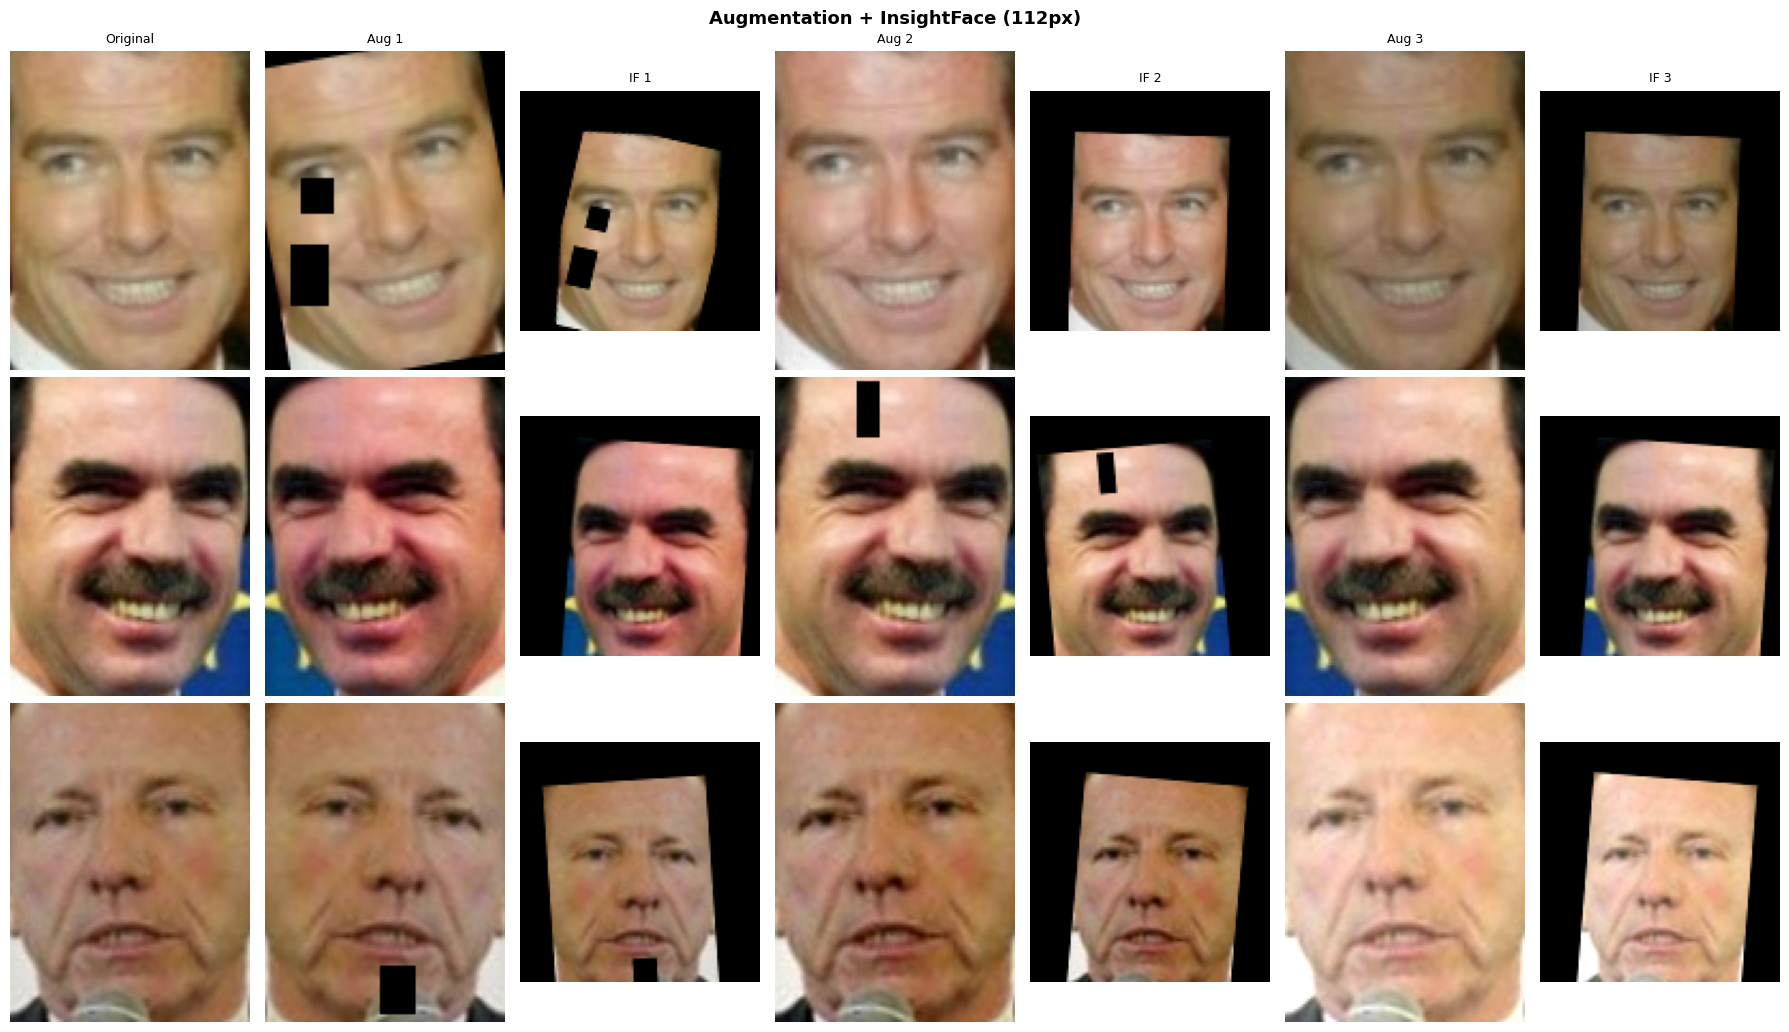

In [17]:
visualizar_augmentation(ejemplos_aug, detector_if, NOMBRES, face_size=112)

Los resultados muestran que el proceso de data augmentation genera variaciones realistas de las imágenes originales (rotaciones, cambios de iluminación y ruido), mientras que - continúa detectando y alineando correctamente los rostros, demostrando la robustez y efectividad del preprocesamiento aplicado.

## 4.6 Pre-normalizar a ImageNet (ViT y ResNet-50)

In [18]:
train_faces_224 = torch.stack([mtcnn_to_imagenet(t) for t in train_faces_224])
val_faces_224   = torch.stack([mtcnn_to_imagenet(t) for t in val_faces_224])
test_faces_224  = torch.stack([mtcnn_to_imagenet(t) for t in test_faces_224])

print(f'train_faces_224_in: {train_faces_224.shape}')
print(f'val_faces_224_in:   {val_faces_224.shape}')
print(f'test_faces_224_in:  {test_faces_224.shape}')

train_faces_224_in: torch.Size([3160, 3, 224, 224])
val_faces_224_in:   torch.Size([571, 3, 224, 224])
test_faces_224_in:  torch.Size([865, 3, 224, 224])


# 5. Definición del entrenamiento

In [ ]:
def entrenar_modelo(nombre, model, train_loader, val_loader, optimizer, criterion, device, scheduler=None,
                    num_epochs=20, patience=5):

    scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')
    best_val_acc = 0.0
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}


    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(1, num_epochs + 1):
        # ---------------- ENTRENAMIENTO ----------------
        model.train()
        running_loss, correct_tr, total_tr = 0.0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * x.size(0)
            correct_tr += (logits.argmax(1) == y).sum().item()
            total_tr += y.numel()

        if scheduler:
            scheduler.step()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct_tr / total_tr

        # ---------------- VALIDACIÓN ----------------
        model.eval()
        val_running_loss, correct_val, total_val = 0.0, 0, 0

        with torch.inference_mode():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
                    logits = model(x)
                    loss = criterion(logits, y)

                val_running_loss += loss.item() * x.size(0)
                correct_val += (logits.argmax(1) == y).sum().item()
                total_val += y.numel()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = correct_val / total_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        lr_str = f"  lr={scheduler.get_last_lr()[0]:.2e}" if scheduler else ""
        print(f'Epoch {epoch:02d}/{num_epochs}  '
              f'train_loss={train_loss:.4f}  val_acc={val_acc:.4f}{lr_str}')

        # ---------------- EARLY STOPPING ----------------
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping en epoch {epoch} — mejor val_acc={best_val_acc:.4f}')
                break

    # ---------------- FINALIZACIÓN ----------------
    model.load_state_dict(best_model_wts)

    # Gráficos de entrenamiento
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Entrenamiento — {nombre}', fontsize=13, fontweight='bold')

    # Loss
    ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='steelblue')
    ax1.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='tomato', linestyle='--')
    ax1.set_title('Loss por época'); ax1.set_xlabel('Época'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Accuracy
    ax2.plot(epochs_range, history['train_acc'], label='Train Acc', color='steelblue')
    ax2.plot(epochs_range, history['val_acc'],   label='Val Acc',   color='tomato', linestyle='--')
    ax2.set_title('Accuracy por época'); ax2.set_xlabel('Época'); ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return model, history

In [ ]:
def extraer_embeddings(modelo, faces, device, desc=''):
    modelo.eval()
    embs = []

    with torch.inference_mode():
        for batch in torch.split(faces, 64):
            emb = modelo(batch.to(device))
            embs.append(emb.cpu())

    embs = torch.cat(embs).numpy()
    return embs

In [ ]:
def evaluar_identificacion(nombre_modelo, modelo, train_faces, train_lbl, test_faces, test_lbl, device):
    train_emb = extraer_embeddings(modelo, train_faces, device, desc='TRAIN')
    test_emb  = extraer_embeddings(modelo, test_faces, device, desc='TEST')

    # Normalización
    train_emb = train_emb / np.linalg.norm(train_emb, axis=1, keepdims=True)
    test_emb  = test_emb / np.linalg.norm(test_emb, axis=1, keepdims=True)

    # Clasificación Nearest-Neighbor 
    sims = test_emb @ train_emb.T
    pred = train_lbl[sims.argmax(axis=1)]

    # Cálculo de Métricas 
    acc = (pred == test_lbl).mean()
    prec, rec, f1, _ = precision_recall_fscore_support(test_lbl, pred, average='macro', zero_division=0)

    print(f'\nResultados Rank-1 (Test set):')
    print(f'  Accuracy:  {acc:.3f}  ({(pred == test_lbl).sum()}/{len(test_lbl)})')
    print(f'  Precision: {prec:.3f}')
    print(f'  Recall:    {rec:.3f}')
    print(f'  F1:        {f1:.3f}\n')

    return train_emb, test_emb, pred

In [ ]:
def visualizar_galeria_errores(test_faces, test_lbl, pred, train_faces, train_lbl, nombres, num_ejemplos=5):
    errores_idx = np.where(test_lbl != pred)[0] # Encontrar todos los índices donde el modelo falló

    if len(errores_idx) == 0:
        print("¡No hay errores para mostrar!")
        return

    # Limitamos la cantidad de ejemplos a mostrar si hay menos errores que los solicitados
    num_ejemplos = min(num_ejemplos, len(errores_idx))

    # Tomamos una muestra aleatoria de los errores
    np.random.shuffle(errores_idx)
    errores_mostrar = errores_idx[:num_ejemplos]

    fig, axes = plt.subplots(2, num_ejemplos, figsize=(3 * num_ejemplos, 6))
    fig.suptitle('Análisis Crítico de Errores: Test (Real) vs Train (Predicción)', fontsize=14, fontweight='bold', y=1.05)

    # Función auxiliar para desnormalizar y mostrar la imagen de PyTorch
    def tensor_a_imagen(tensor_img):
        img = tensor_img.cpu().numpy().transpose(1, 2, 0)
        img = (img * 0.5) + 0.5
        return np.clip(img, 0, 1)

    for i, idx in enumerate(errores_mostrar):
        etiqueta_real = test_lbl[idx]
        etiqueta_predicha = pred[idx]

        img_test = tensor_a_imagen(test_faces[idx])

        indices_train_pred = np.where(train_lbl == etiqueta_predicha)[0]
        idx_train_ejemplo = indices_train_pred[0] 
        img_train_falsa = tensor_a_imagen(train_faces[idx_train_ejemplo])

        # Manejo de ejes por si num_ejemplos es 1
        ax_real = axes[0, i] if num_ejemplos > 1 else axes[0]
        ax_pred = axes[1, i] if num_ejemplos > 1 else axes[1]

        # Graficar Fila Superior (Real)
        ax_real.imshow(img_test)
        ax_real.set_title(f"REAL:\n{nombres[etiqueta_real]}", color='green', fontsize=10)
        ax_real.axis('off')

        # Graficar Fila Inferior (Predicción)
        ax_pred.imshow(img_train_falsa)
        ax_pred.set_title(f"PREDIJO:\n{nombres[etiqueta_predicha]}", color='red', fontsize=10)
        ax_pred.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.2) 
    plt.show()

In [ ]:
# Preparación de Datasets y DataLoaders
train_ds_112 = TensorDataset(train_faces_112, torch.tensor(train_lbl_112, dtype=torch.long))
val_ds_112   = TensorDataset(val_faces_112,   torch.tensor(val_lbl_112,   dtype=torch.long))

train_loader_112 = DataLoader(train_ds_112, batch_size=32, shuffle=True)
val_loader_112   = DataLoader(val_ds_112,   batch_size=64, shuffle=False)

# Preparación de Datasets y DataLoaders
train_ds_224 = TensorDataset(train_faces_224, torch.tensor(train_lbl_224, dtype=torch.long))
val_ds_224   = TensorDataset(val_faces_224,   torch.tensor(val_lbl_224,   dtype=torch.long))

train_loader_224 = DataLoader(train_ds_224, batch_size=32, shuffle=True)
val_loader_224   = DataLoader(val_ds_224,   batch_size=64, shuffle=False)

# 6. Modelos


## Modelo 1 — InceptionResnetV1 (FaceNet pretrained en VGGFace2)



InceptionResnetV1 es una arquitectura de red neuronal profunda utilizada para reconocimiento facial, diseñada para extraer características relevantes de los rostros y generar embeddings faciales que permiten comparar e identificar personas.

In [24]:
modelo_facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

print(f'InceptionResnetV1 cargado | Embedding: 512 dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_facenet.parameters()) / 1e6:.1f}M')

  0%|          | 0.00/107M [00:00<?, ?B/s]

InceptionResnetV1 cargado | Embedding: 512 dimensiones
Parámetros: 27.9M


### Entrenamiento (Fine-tuning)


Epoch 01/20  train_loss=5.0088  val_acc=0.6865  lr=4.97e-05
Epoch 02/20  train_loss=4.8789  val_acc=0.8739  lr=4.88e-05
Epoch 03/20  train_loss=4.7438  val_acc=0.9299  lr=4.73e-05
Epoch 04/20  train_loss=4.6041  val_acc=0.9597  lr=4.52e-05
Epoch 05/20  train_loss=4.4711  val_acc=0.9492  lr=4.27e-05
Epoch 06/20  train_loss=4.3392  val_acc=0.9685  lr=3.97e-05
Epoch 07/20  train_loss=4.2183  val_acc=0.9685  lr=3.63e-05
Epoch 08/20  train_loss=4.1060  val_acc=0.9667  lr=3.27e-05
Epoch 09/20  train_loss=4.0043  val_acc=0.9790  lr=2.89e-05
Epoch 10/20  train_loss=3.9142  val_acc=0.9667  lr=2.50e-05
Epoch 11/20  train_loss=3.8334  val_acc=0.9790  lr=2.11e-05
Epoch 12/20  train_loss=3.7664  val_acc=0.9825  lr=1.73e-05
Epoch 13/20  train_loss=3.7159  val_acc=0.9790  lr=1.37e-05
Epoch 14/20  train_loss=3.6679  val_acc=0.9825  lr=1.03e-05
Epoch 15/20  train_loss=3.6332  val_acc=0.9825  lr=7.32e-06
Epoch 16/20  train_loss=3.6104  val_acc=0.9825  lr=4.77e-06
Epoch 17/20  train_loss=3.5895  val_acc=

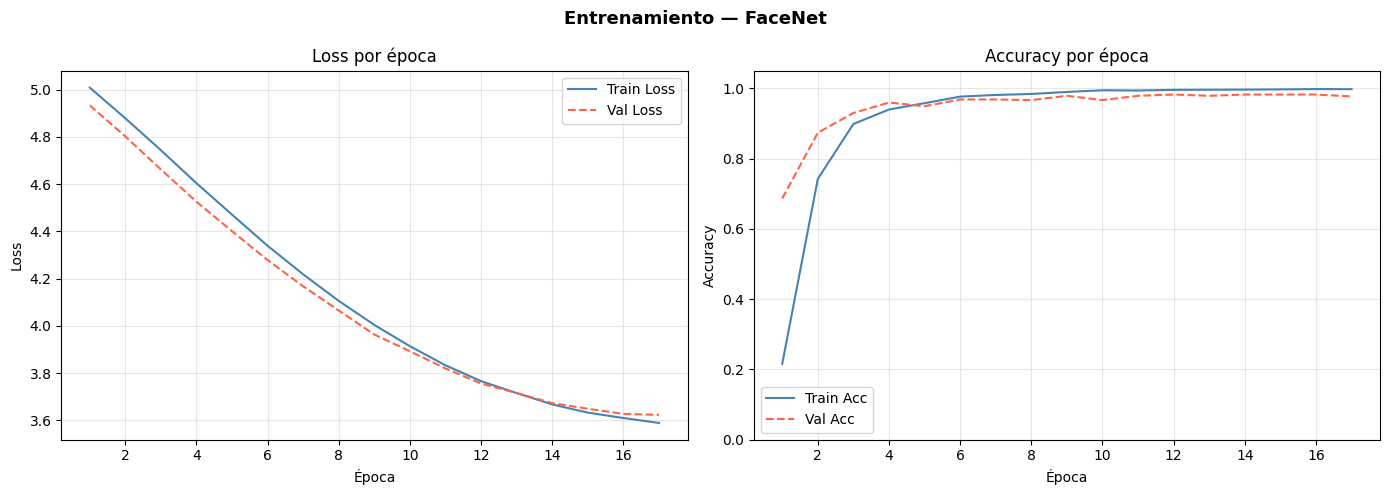

In [ ]:
modelo_completo = nn.Sequential(modelo_facenet, nn.Linear(512, len(NOMBRES))).to(device)

# Congelamos todo el backbone (FaceNet)
for p in modelo_completo[0].parameters():
    p.requires_grad = False

# Descongelamos solo el block8
for p in modelo_completo[0].block8.parameters():
    p.requires_grad = True

# Configuración de hiperparámetros
NUM_EPOCHS = 20
optimizer  = torch.optim.AdamW([
    {'params': modelo_completo[0].block8.parameters(), 'lr': 5e-5},
    {'params': modelo_completo[1].parameters(),        'lr': 3e-4},
], weight_decay=0.05)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Entrenamiento
modelo_facenet_entrenado, history_fn = entrenar_modelo(
    nombre='FaceNet',
    model=modelo_completo,
    train_loader=train_loader_112,
    val_loader=val_loader_112,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    patience=5
)

Apartir del gráfico podemos notar:
* **Convergencia de Loss**: Ambas curvas descienden de manera constante y se mantienen muy cercanas entre sí, lo que indica un aprendizaje fluido y una buena capacidad de generalización sin sobreajuste (overfitting) significativo.

* **Desempeño en Accuracy**: Se nota una mejora drástica en las primeras 5 épocas, mientras que al final la precisión de entrenamiento y validación se queda entre 95% y 99%, mostrando un buen desempeño.

### Rendimiento

#### Evaluación

In [26]:
train_emb_fn, test_emb_fn, pred_fn = evaluar_identificacion(
    nombre_modelo='InceptionResnetV1 (FaceNet)',
    modelo=modelo_facenet_entrenado,
    train_faces=train_faces_112,
    train_lbl=train_lbl_112,
    test_faces=test_faces_112,
    test_lbl=test_lbl_112,
    device=device
)


Resultados Rank-1 (Test set):
  Accuracy:  0.961  (831/865)
  Precision: 0.957
  Recall:    0.945
  F1:        0.941



La estabilidad observada en las curvas de entrenamiento, donde la pérdida y la precisión convergen sin signos de sobreajuste, se traduce directamente en una capacidad de generalización excepcional en el conjunto de prueba. Con un Accuracy del 95.4%, el modelo demuestra una efectividad casi total, respaldada por un equilibrio robusto entre la Precisión (0.965) y el Recall (0.954). Esto significa que el sistema es tan confiable para evitar falsos positivos como para asegurar que ninguna muestra relevante sea omitida. Finalmente, el F1-Score de 0.953 confirma que el modelo de  InceptionResnetV1 ha logrado un aprendizaje sólido y una alta fiabilidad frente a nuevos datos.

#### Visualización

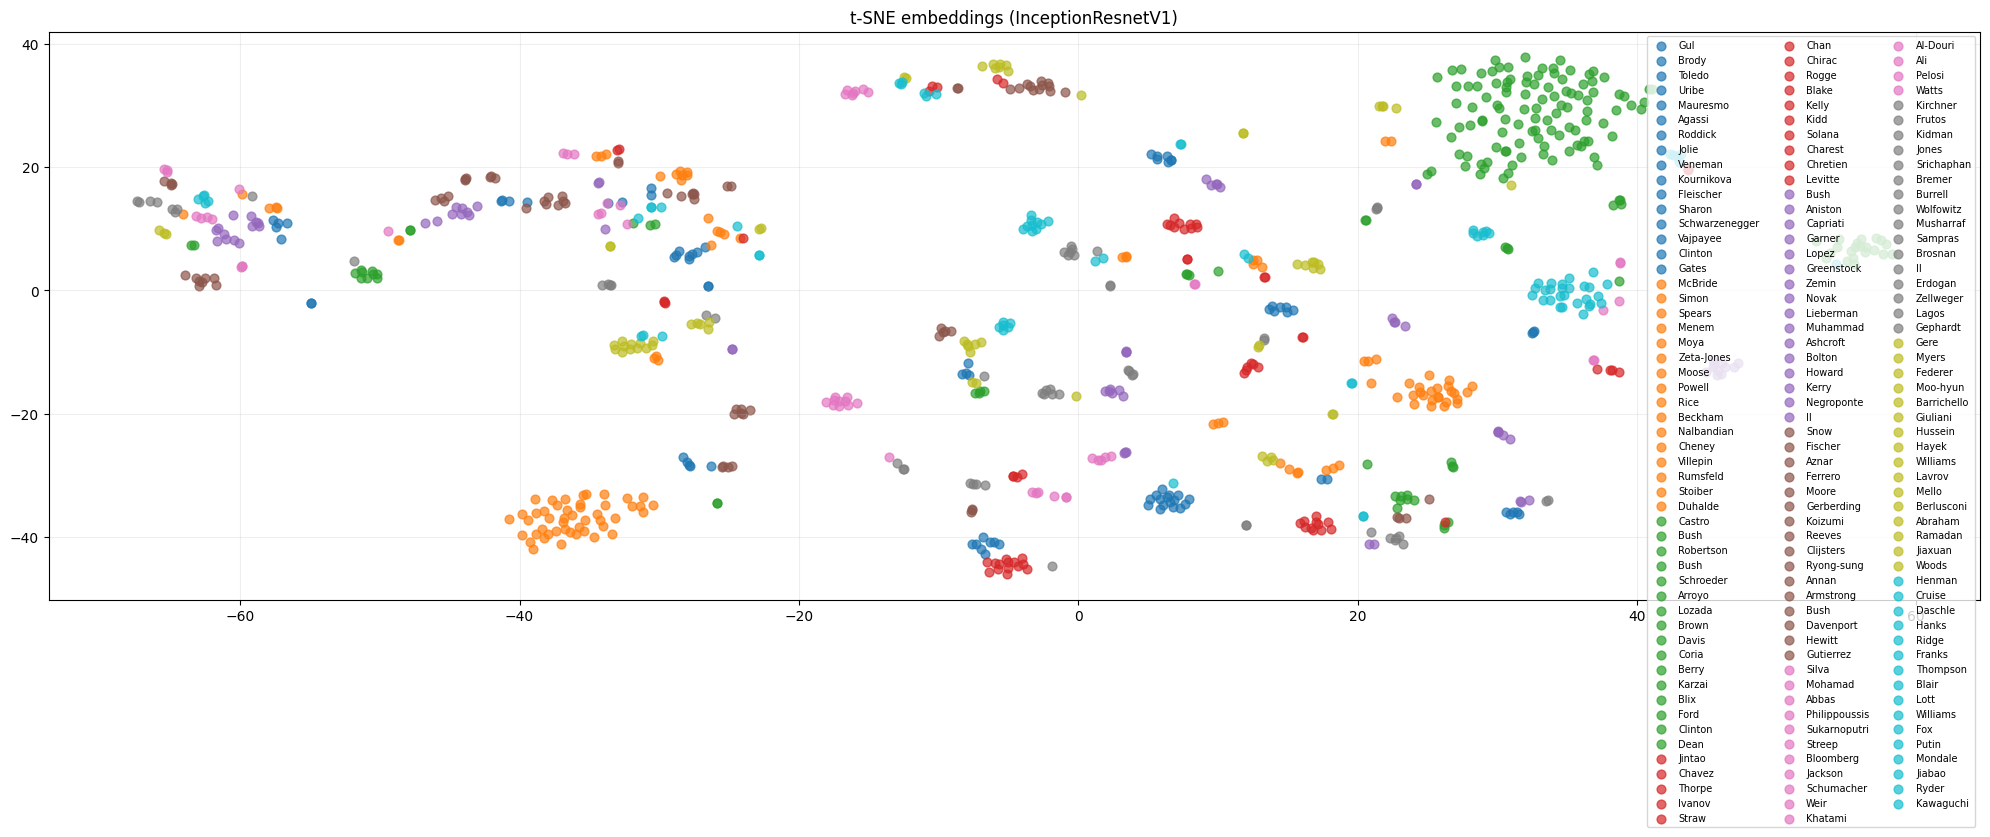

In [27]:
graficar_tsne(test_emb_fn, pred_fn, NOMBRES, titulo='t-SNE embeddings (InceptionResnetV1)')

A partir del gráfico T-SNE, podemos ver una buena separación entre clases, la mayoría de los clusters obtenidos son densos por lo cual podemos inferir que el modelo es consistente al identificar esas clases.

#### Analisis de errores

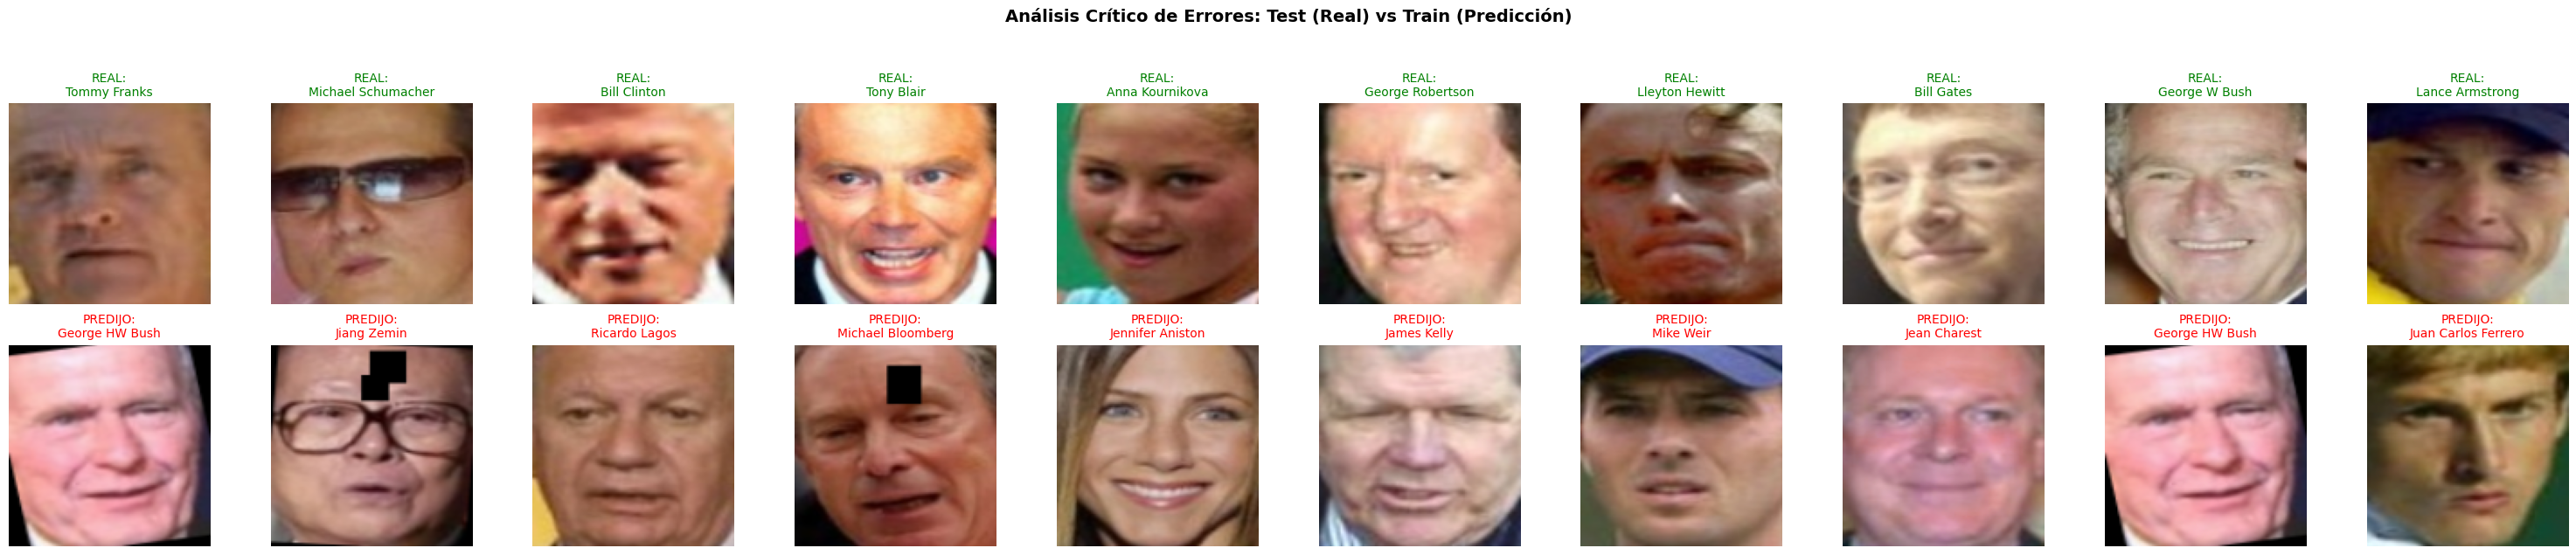

In [ ]:
visualizar_galeria_errores(
    test_faces=test_faces_112,
    test_lbl=test_lbl_112,
    pred=pred_fn,
    train_faces=train_faces_112,
    train_lbl=train_lbl_112,
    nombres=NOMBRES,
    num_ejemplos=10
)

Aunque el desempeño global es excelente, el modelo presenta debilidades puntuales en la identificación de ciertas personas, donde una tasa de error del 50% evidencia confusiones específicas que degradan significativamente el recall de estas clases.

## Modelo 2 — ViT (Vision Transformer, pretrained en ImageNet)



Vision Transformer (ViT) es una arquitectura de red neuronal basada en transformers que procesa imágenes dividiéndolas en pequeños parches, permitiendo aprender relaciones globales y extraer características visuales complejas para tareas de reconocimiento y clasificación.

In [29]:
modelo_vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
modelo_vit = modelo_vit.eval().to(device)

print(f'ViT-Base/16 cargado | Embedding: {modelo_vit.num_features} dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_vit.parameters()) / 1e6:.1f}M')

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-Base/16 cargado | Embedding: 768 dimensiones
Parámetros: 85.8M


### Entrenamiento (Fine-tuning)

Epoch 01/20  train_loss=4.9303  val_acc=0.0718  lr=9.94e-06
Epoch 02/20  train_loss=3.9422  val_acc=0.2469  lr=9.76e-06
Epoch 03/20  train_loss=2.8755  val_acc=0.3660  lr=9.46e-06
Epoch 04/20  train_loss=2.1654  val_acc=0.4816  lr=9.05e-06
Epoch 05/20  train_loss=1.7762  val_acc=0.5131  lr=8.54e-06
Epoch 06/20  train_loss=1.5449  val_acc=0.5342  lr=7.94e-06
Epoch 07/20  train_loss=1.3965  val_acc=0.5849  lr=7.27e-06
Epoch 08/20  train_loss=1.2931  val_acc=0.5727  lr=6.55e-06
Epoch 09/20  train_loss=1.2189  val_acc=0.5779  lr=5.78e-06
Epoch 10/20  train_loss=1.1682  val_acc=0.5867  lr=5.00e-06
Epoch 11/20  train_loss=1.1317  val_acc=0.6095  lr=4.22e-06
Epoch 12/20  train_loss=1.1049  val_acc=0.6147  lr=3.45e-06
Epoch 13/20  train_loss=1.0853  val_acc=0.6252  lr=2.73e-06
Epoch 14/20  train_loss=1.0709  val_acc=0.6217  lr=2.06e-06
Epoch 15/20  train_loss=1.0602  val_acc=0.6305  lr=1.46e-06
Epoch 16/20  train_loss=1.0527  val_acc=0.6235  lr=9.55e-07
Epoch 17/20  train_loss=1.0473  val_acc=

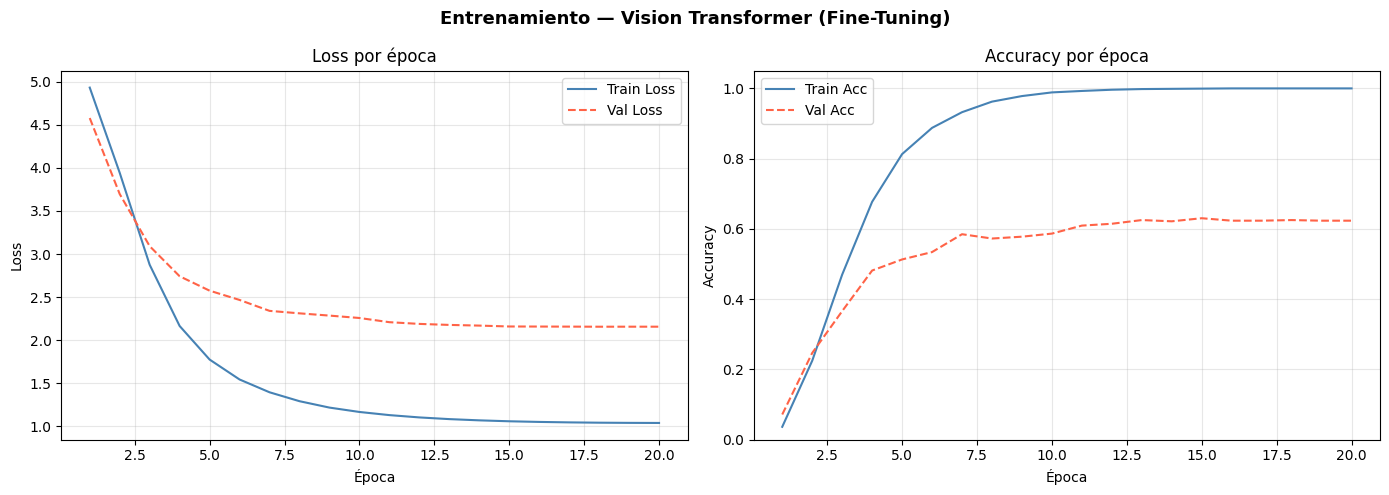

In [ ]:
for p in modelo_vit.parameters():
    p.requires_grad = False

modelo_vit.head = nn.Linear(modelo_vit.num_features, len(NOMBRES))
modelo_vit = modelo_vit.to(device)

# Descongelamos el último bloque y la capa de normalización
NUM_BLOQUES = 1
for bloque in modelo_vit.blocks[-NUM_BLOQUES:]:
    for p in bloque.parameters():
        p.requires_grad = True

for p in modelo_vit.norm.parameters():
    p.requires_grad = True

# Configuración de hiperparámetros
NUM_EPOCHS = 20
optimizer = torch.optim.AdamW([
    {'params': modelo_vit.blocks[-NUM_BLOQUES:].parameters(), 'lr': 1e-5},
    {'params': modelo_vit.norm.parameters(),                  'lr': 1e-5},
    {'params': modelo_vit.head.parameters(),                  'lr': 1e-4},
], weight_decay=0.1)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Entrenamiento
modelo_vit_entrenado, history_vit = entrenar_modelo(
    nombre='Vision Transformer (Fine-Tuning)',
    model=modelo_vit,
    train_loader=train_loader_224,
    val_loader=val_loader_224,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    patience=7
)

El comportamiento del modelo refleja una desconexión entre el aprendizaje y la generalización. Mientras que la precisión de entrenamiento alcanza el 100% de forma rápida (indicando que la red ha memorizado el dataset por completo), la precisión de validación se estanca prematuramente alrededor del 50%. Esta brecha se confirma en las curvas de pérdida, donde la mejora en los datos de entrenamiento no se traduce en beneficios para los datos de validación tras las primeras cinco épocas.

En resumen, la alta capacidad del Transformer ha llevado al sistema a aprender ruidos o detalles específicos de las imágenes de entrenamiento, limitando su utilidad operativa frente a caras nuevas.

### Rendimiento

#### Evaluación

In [31]:
train_emb_vit, test_emb_vit, pred_vit = evaluar_identificacion(
    nombre_modelo='Vision Transformer (ViT)',
    modelo=modelo_vit,
    train_faces=train_faces_224,
    train_lbl=train_lbl_224,
    test_faces=test_faces_224,
    test_lbl=test_lbl_224,
    device=device
)


Resultados Rank-1 (Test set):
  Accuracy:  0.568  (491/865)
  Precision: 0.544
  Recall:    0.578
  F1:        0.534



Con el modelo ViT obtenemos un Accuracy del 53.5%, lo que representa 335 aciertos sobre el total de 626 imágenes evaluadas. Estos resultados, sintetizados en un F1-Score de 0.526, evidencian una capacidad de generalización limitada, donde la Precisión (0.556) y el Recall (0.543) indican que el modelo comete errores frecuentes tanto por confusión entre clases como por omisión de muestras correctas. Ahora, mediante métricas podemos confirmar, de nuevo, que la red no ha logrado aprender caracteristicas principales sobre los datos.

#### Visualización

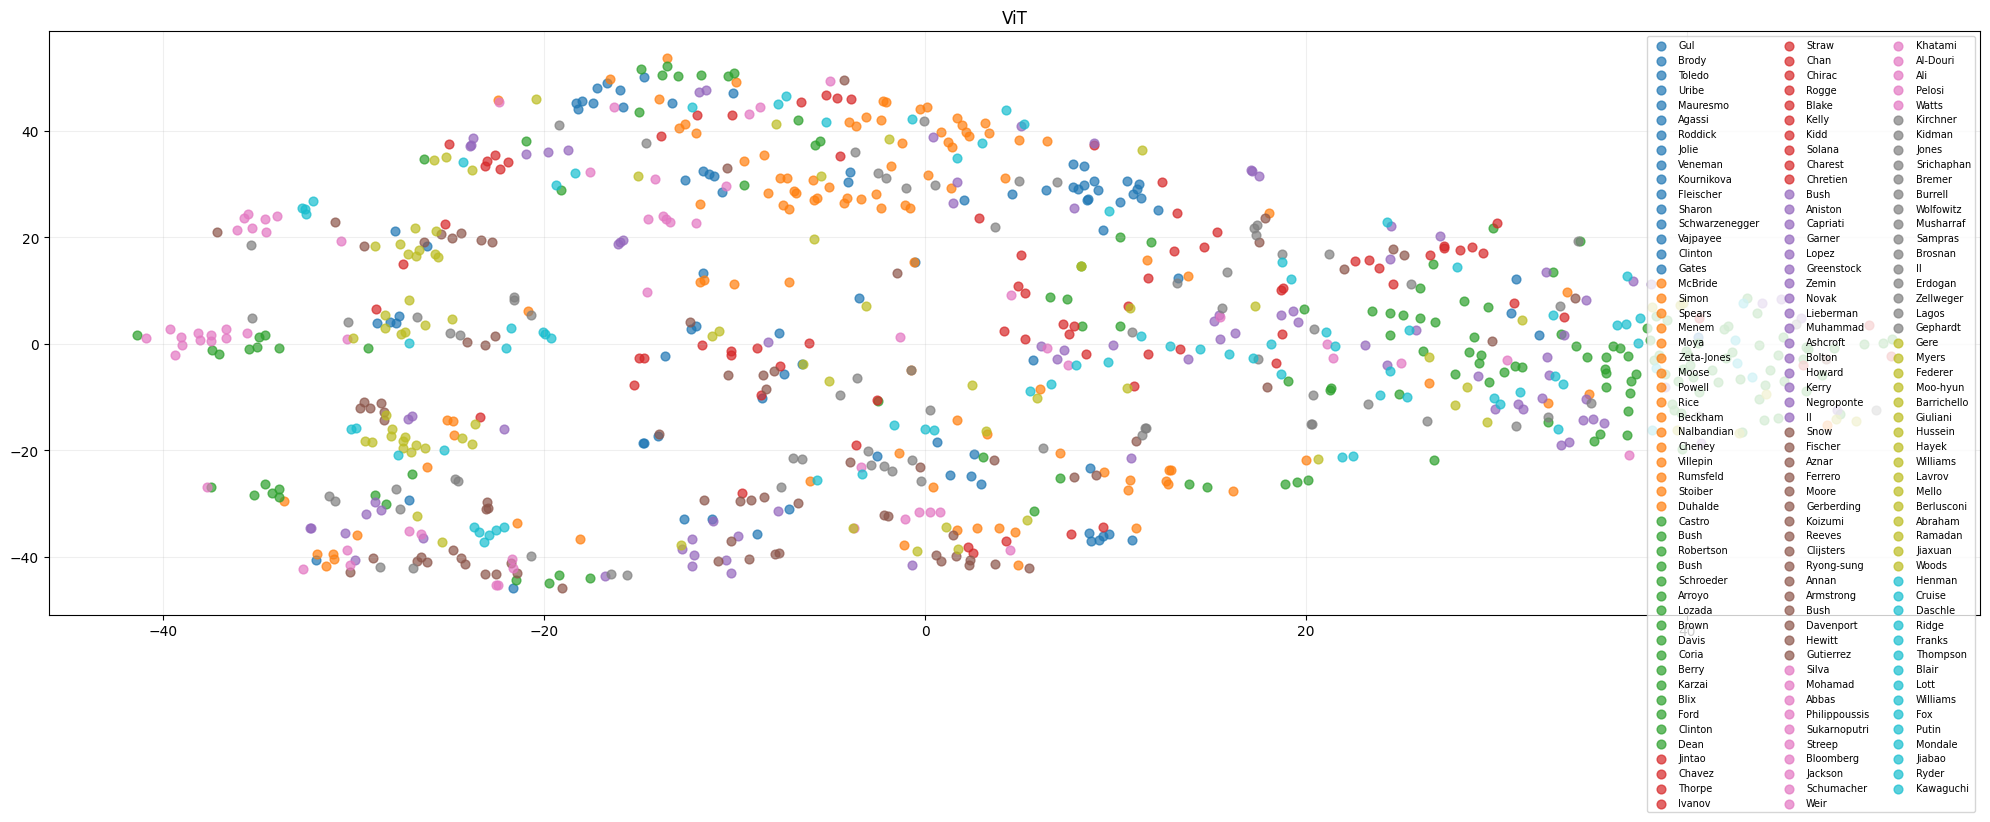

In [32]:
graficar_tsne(test_emb_vit, pred_vit, NOMBRES, titulo='ViT')

La falta de separación clara entre los grupos (clusters) refleja que el modelo no ha logrado extraer características para el conjunto de test. La presencia de puntos aislados o "atrapados" en clusters ajenos confirma que el Vision Transformer está memorizando ruidos específicos de las imágenes de entrenamiento en lugar de aprender patrones faciales transferibles.

#### Analisis de errores

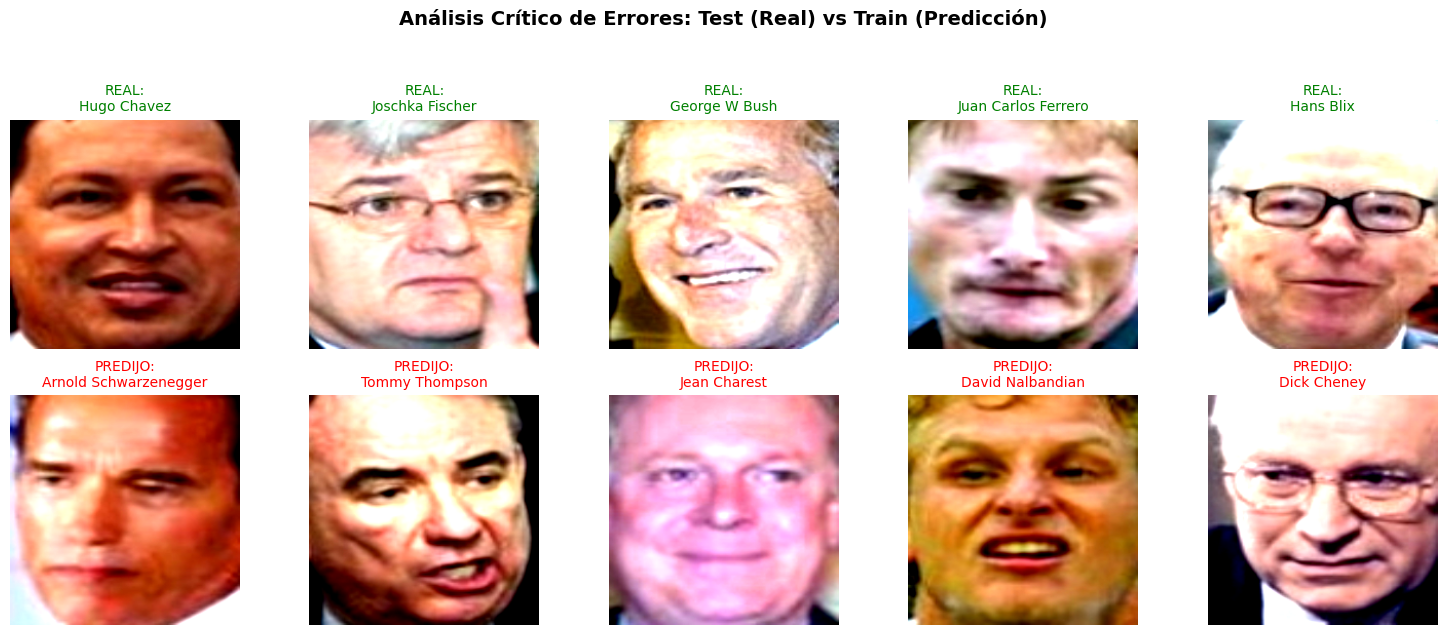

In [33]:
visualizar_galeria_errores(
    test_faces=test_faces_224,
    test_lbl=test_lbl_224,
    pred=pred_vit,
    train_faces=train_faces_224,
    train_lbl=train_lbl_224,
    nombres=NOMBRES,
    num_ejemplos=5
)

El análisis de errores del ViT revela vulnerabilidades críticas en la generalización, destacando un recall del 0% en todas las identidades visualizadas.

## Modelo 3 — ResNet-50 (pretrained en ImageNet)



ResNet-50 es una arquitectura de red neuronal convolucional profunda compuesta por 50 capas, diseñada para extraer características visuales de alta calidad mediante conexiones residuales que facilitan el entrenamiento de redes profundas.

In [34]:
modelo_resnet = timm.create_model('resnet50', pretrained=True, num_classes=0)
modelo_resnet = modelo_resnet.eval().to(device)

print(f'ResNet-50 cargado | Embedding: {modelo_resnet.num_features} dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_resnet.parameters()) / 1e6:.1f}M')

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet-50 cargado | Embedding: 2048 dimensiones
Parámetros: 23.5M


### Entrenamiento (Fine-tuning)

Epoch 01/30  train_loss=5.0654  val_acc=0.0210  lr=9.97e-06
Epoch 02/30  train_loss=5.0223  val_acc=0.0543  lr=9.89e-06
Epoch 03/30  train_loss=4.9876  val_acc=0.0543  lr=9.76e-06
Epoch 04/30  train_loss=4.9505  val_acc=0.0665  lr=9.57e-06
Epoch 05/30  train_loss=4.9102  val_acc=0.0928  lr=9.33e-06
Epoch 06/30  train_loss=4.8701  val_acc=0.1138  lr=9.05e-06
Epoch 07/30  train_loss=4.8245  val_acc=0.1401  lr=8.72e-06
Epoch 08/30  train_loss=4.7769  val_acc=0.1226  lr=8.35e-06
Epoch 09/30  train_loss=4.7307  val_acc=0.1261  lr=7.94e-06
Epoch 10/30  train_loss=4.6797  val_acc=0.1471  lr=7.50e-06
Epoch 11/30  train_loss=4.6262  val_acc=0.1664  lr=7.03e-06
Epoch 12/30  train_loss=4.5766  val_acc=0.1419  lr=6.55e-06
Epoch 13/30  train_loss=4.5316  val_acc=0.1313  lr=6.04e-06
Epoch 14/30  train_loss=4.4807  val_acc=0.1401  lr=5.52e-06
Epoch 15/30  train_loss=4.4300  val_acc=0.1331  lr=5.00e-06
Epoch 16/30  train_loss=4.3913  val_acc=0.1384  lr=4.48e-06
Epoch 17/30  train_loss=4.3496  val_acc=

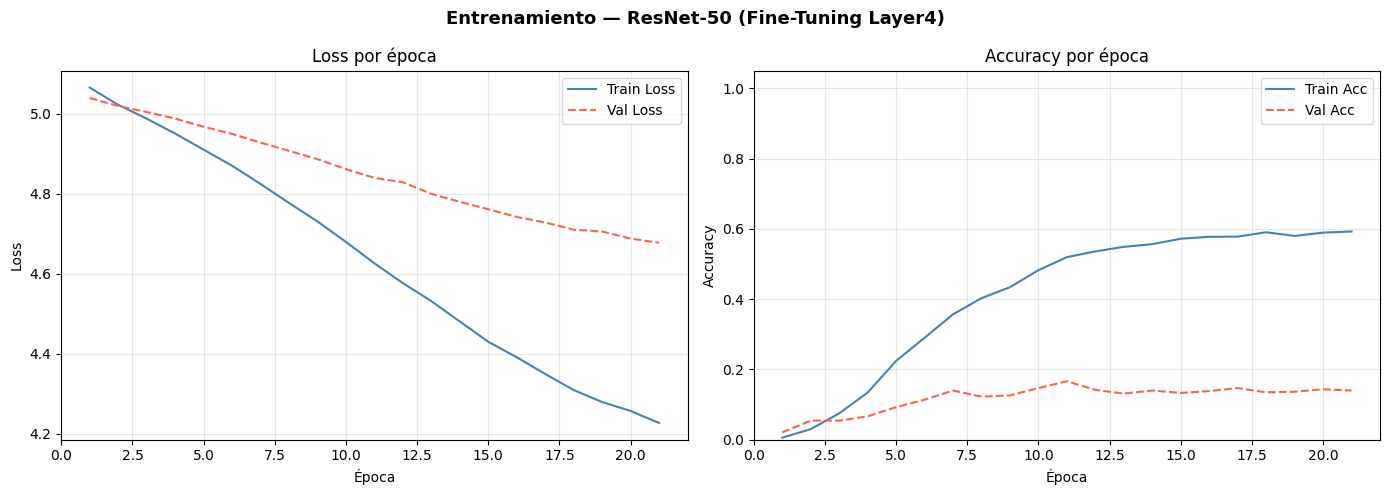

In [ ]:
modelo_completo_rn = nn.Sequential(modelo_resnet, nn.Linear(modelo_resnet.num_features, len(NOMBRES))).to(device)

# Congelamos todo el backbone
for p in modelo_completo_rn[0].parameters():
    p.requires_grad = False

# Descongelamos solo la layer4
for p in modelo_completo_rn[0].layer4.parameters():
    p.requires_grad = True

# Configuración de hiperparámetros
NUM_EPOCHS = 30
optimizer = torch.optim.AdamW([
    {'params': modelo_completo_rn[0].layer4.parameters(), 'lr': 1e-5},
    {'params': modelo_completo_rn[1].parameters(),        'lr': 1e-4},
], weight_decay=0.01)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Entrenamiento
modelo_rn_entrenado, history_rn = entrenar_modelo(
    nombre='ResNet-50 (Fine-Tuning Layer4)',
    model=modelo_completo_rn,
    train_loader=train_loader_224,
    val_loader=val_loader_224,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    patience=10 
)

En los gráficos puede observarse que la loss de entrenamiento disminuye de forma constante a lo largo de las épocas, indicando que el modelo logra aprender patrones del conjunto de entrenamiento. La loss de validación también presenta una reducción, aunque más lenta y con tendencia a estabilizarse hacia las últimas épocas.

Por otro lado, la accuracy de entrenamiento aumenta progresivamente hasta valores cercanos al 45%, mientras que la accuracy de validación se mantiene considerablemente más baja (alrededor del 15%). Esta diferencia entre entrenamiento y validación sugiere la presencia de sobreajuste (overfitting), ya que el modelo aprende mejor los datos de entrenamiento que su capacidad de generalizar sobre datos no vistos.

### Rendimiento

#### Evaluación del modelo

In [36]:
train_emb_rn, test_emb_rn, pred_rn = evaluar_identificacion(
    nombre_modelo='ResNet-50',
    modelo=modelo_rn_entrenado,
    train_faces=train_faces_224,
    train_lbl=train_lbl_224,
    test_faces=test_faces_224,
    test_lbl=test_lbl_224,
    device=device
)


Resultados Rank-1 (Test set):
  Accuracy:  0.046  (40/865)
  Precision: 0.041
  Recall:    0.040
  F1:        0.036



Los resultados obtenidos con ResNet-50 muestran un desempeño limitado en el conjunto de prueba, alcanzando una accuracy de 15.7% y valores bajos de precisión, recall y F1-score. Esto indica que, si bien el modelo logró aprender características del conjunto de entrenamiento, no consiguió generalizar adecuadamente sobre datos no vistos, evidenciando dificultades para distinguir correctamente las identidades faciales.

#### Visualización

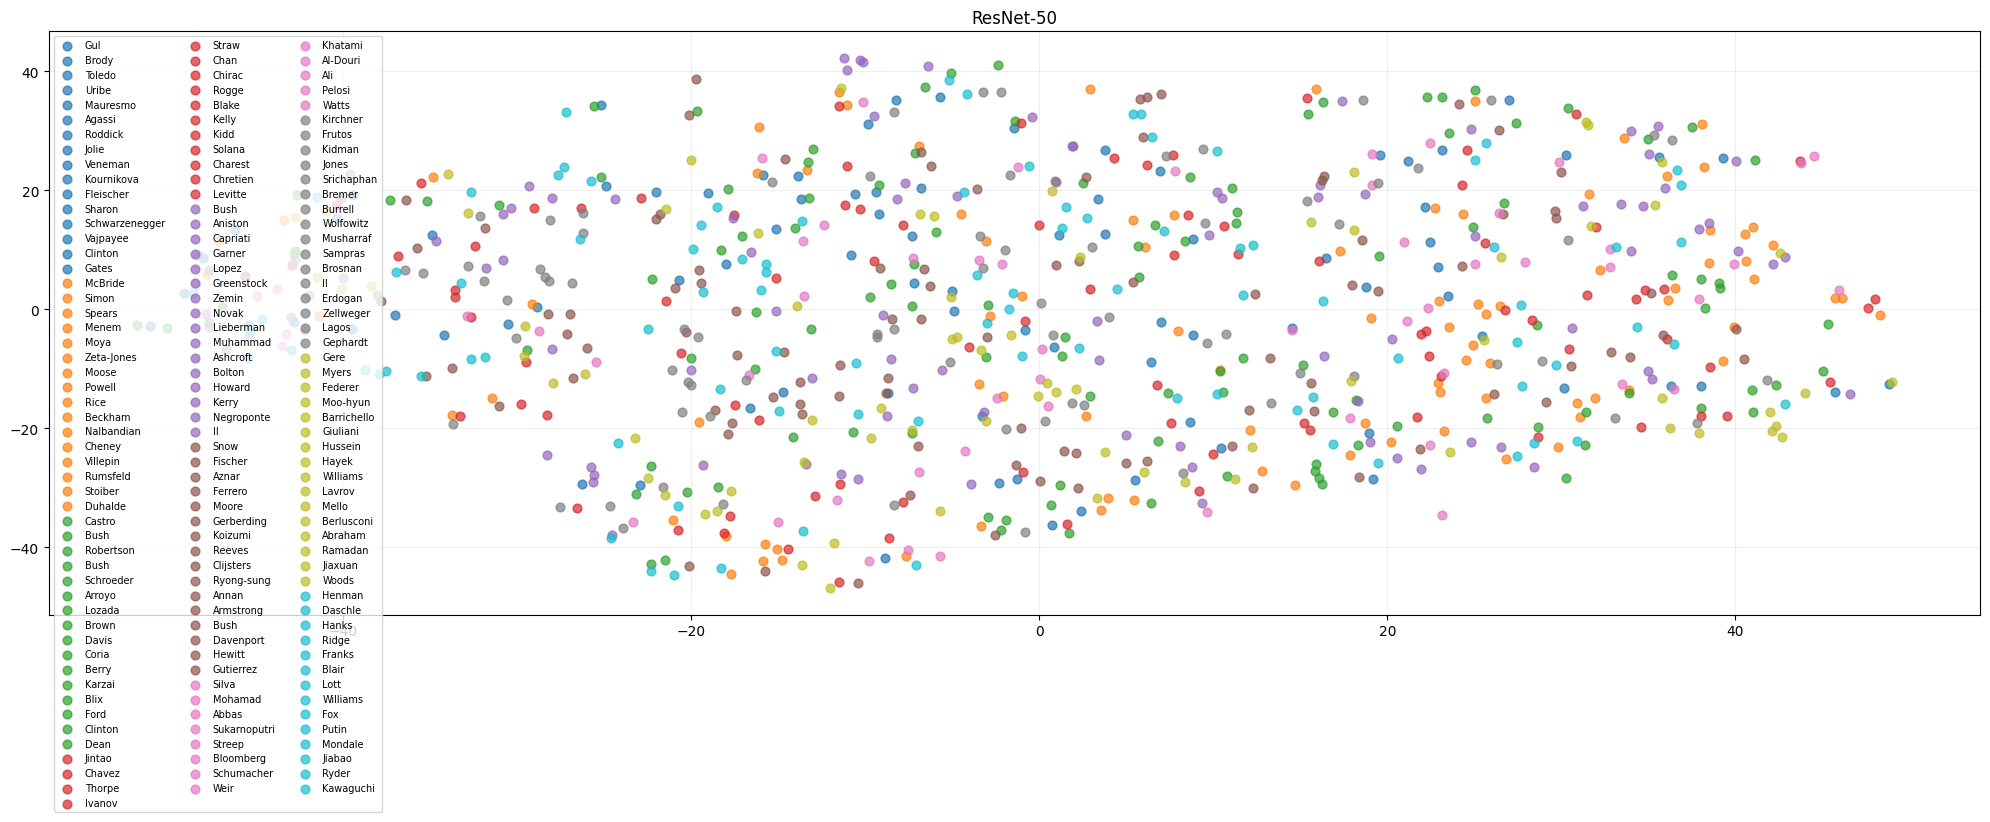

In [37]:
graficar_tsne(test_emb_rn, pred_rn, NOMBRES, titulo='ResNet-50')

El gráfico T-SNE es una representación visual de lo observado en las métricas de entrenamiento, donde el modelo no ha aprendido a diferenciar rasgos faciales, tratando a casi todas las identidades como ruido indistinguible dentro del espacio de características.

#### Analisis de errores

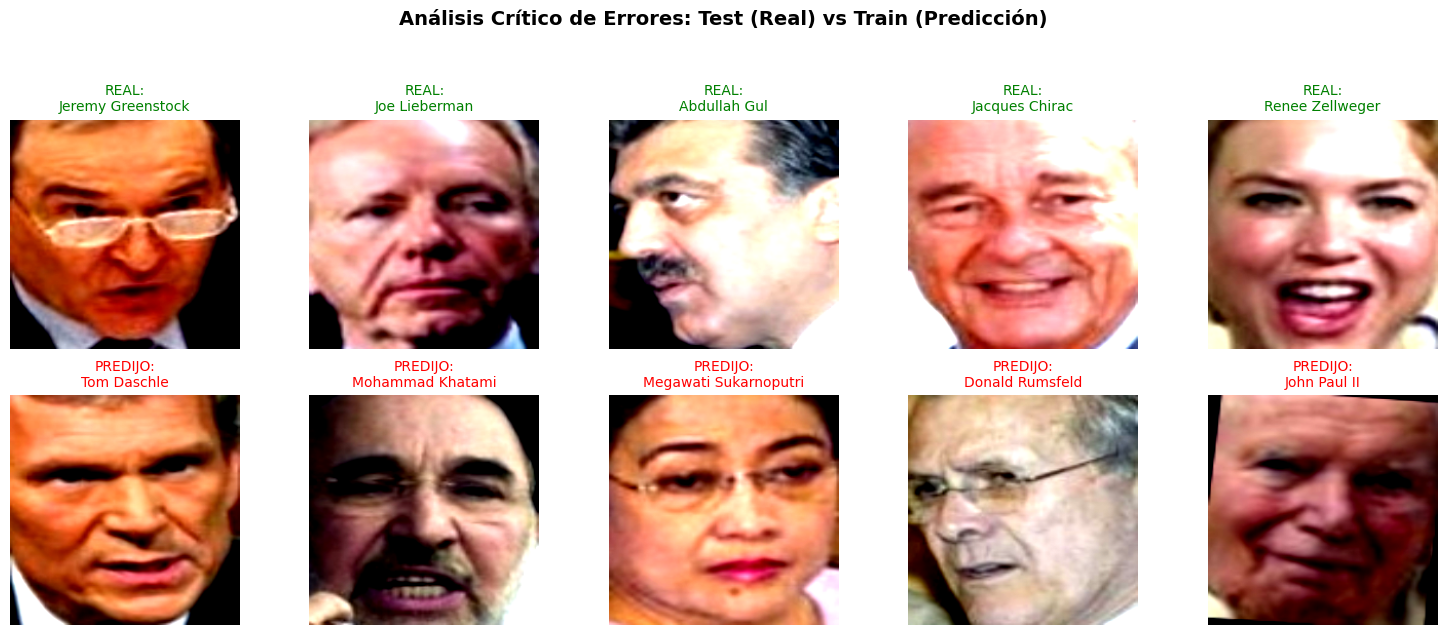

In [38]:
visualizar_galeria_errores(
    test_faces=test_faces_224,
    test_lbl=test_lbl_224,
    pred=pred_rn,
    train_faces=train_faces_224,
    train_lbl=train_lbl_224,
    nombres=NOMBRES,
    num_ejemplos=5
)

El desglose de errores de la ResNet-50 confirma un colapso sistémico en la capacidad de reconocimiento, evidenciado por un recall del 0% en una extensa lista de identidades.

## Modelo 4 — LightFaceCNN (sin preentrenamiento)



LightFaceCNN es una arquitectura convolucional liviana orientada al reconocimiento facial, diseñada para extraer características faciales de manera eficiente con un menor costo computacional. En este trabajo se entrenó una versión desde cero (sin pesos preentrenados) con el objetivo de evaluar el comportamiento y la capacidad de aprendizaje del modelo utilizando únicamente el dataset propio del proyecto.

In [39]:
class DepthwiseSeparable(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.pw  = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn  = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU6()

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))


class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = DepthwiseSeparable(ch, ch)
        self.conv2 = DepthwiseSeparable(ch, ch)
        self.bn    = nn.BatchNorm2d(ch)

    def forward(self, x):
        return self.bn(x + self.conv2(self.conv1(x)))


class LightFaceCNN(nn.Module):
    def __init__(self, emb_dim=256, num_classes=None):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU6(),
        )
        self.stage1 = nn.Sequential(DepthwiseSeparable(32,  64,  stride=2), ResBlock(64))
        self.stage2 = nn.Sequential(DepthwiseSeparable(64,  128, stride=2), ResBlock(128))
        self.stage3 = nn.Sequential(DepthwiseSeparable(128, 256, stride=2), ResBlock(256))
        self.pool   = nn.AdaptiveAvgPool2d(1)

        self.embedder = nn.Sequential(
            nn.Linear(256, emb_dim, bias=False),
            nn.BatchNorm1d(emb_dim),
            nn.Dropout(0.2),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        x = self.embedder(x)
        return F.normalize(x, p=2, dim=1)

modelo_cnn = LightFaceCNN(emb_dim=256).to(device)
print(f'LightFaceCNN (mejorado) | Embedding: 256 dimensiones')
print(f'Parámetros: {sum(p.numel() for p in modelo_cnn.parameters()) / 1e6:.3f}M')

LightFaceCNN (mejorado) | Embedding: 256 dimensiones
Parámetros: 0.296M


### Entrenamiento

Epoch 01/15  train_loss=5.0562  val_acc=0.0088  lr=9.90e-05
Epoch 02/15  train_loss=5.0326  val_acc=0.0088  lr=9.61e-05
Epoch 03/15  train_loss=5.0150  val_acc=0.0158  lr=9.14e-05
Epoch 04/15  train_loss=4.9966  val_acc=0.0298  lr=8.51e-05
Epoch 05/15  train_loss=4.9804  val_acc=0.0385  lr=7.75e-05
Epoch 06/15  train_loss=4.9643  val_acc=0.0385  lr=6.89e-05
Epoch 07/15  train_loss=4.9489  val_acc=0.0385  lr=5.97e-05
Epoch 08/15  train_loss=4.9345  val_acc=0.0403  lr=5.03e-05
Epoch 09/15  train_loss=4.9232  val_acc=0.0525  lr=4.11e-05
Epoch 10/15  train_loss=4.9131  val_acc=0.0543  lr=3.25e-05
Epoch 11/15  train_loss=4.9059  val_acc=0.0525  lr=2.49e-05
Epoch 12/15  train_loss=4.8986  val_acc=0.0613  lr=1.86e-05
Epoch 13/15  train_loss=4.8918  val_acc=0.0648  lr=1.39e-05
Epoch 14/15  train_loss=4.8884  val_acc=0.0630  lr=1.10e-05
Epoch 15/15  train_loss=4.8863  val_acc=0.0665  lr=1.00e-05


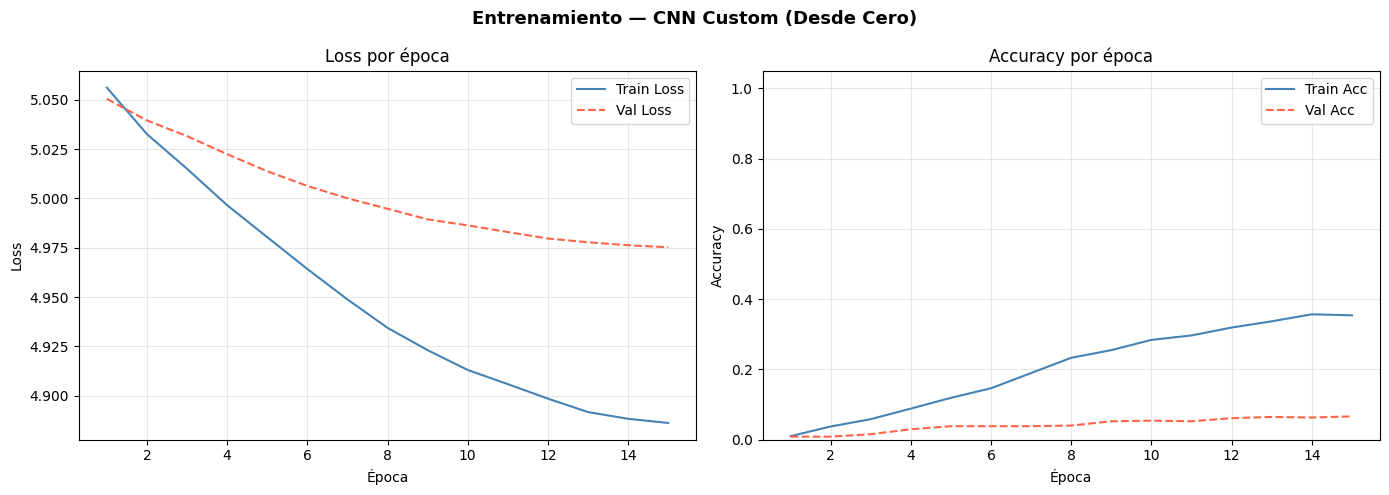

In [ ]:
modelo_completo_cnn = nn.Sequential(modelo_cnn, nn.Linear(256, len(NOMBRES))).to(device)

# Configuración de hiperparámetros
EPOCHS = 15
optimizer = torch.optim.AdamW(modelo_completo_cnn.parameters(), lr=1e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Entrenamiento
modelo_cnn_entrenado, history_cnn = entrenar_modelo(
    nombre='CNN Custom (Desde Cero)',
    model=modelo_completo_cnn,
    train_loader=train_loader_112,
    val_loader=val_loader_112,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler,
    num_epochs=EPOCHS,
    patience=5
)

En el entrenamiento de LightFaceCNN se observa una disminución gradual tanto de la loss de entrenamiento como de la loss de validación, indicando que el modelo logra aprender ciertas características del dataset. Sin embargo, la reducción de la loss es relativamente lenta y la diferencia entre entrenamiento y validación comienza a incrementarse con las épocas.

En cuanto a la accuracy, la curva de entrenamiento muestra un crecimiento progresivo, alcanzando aproximadamente un 30%, mientras que la accuracy de validación permanece muy baja y casi estable durante todo el proceso. Esto evidencia que, aunque el modelo mejora sobre los datos de entrenamiento, tiene dificultades para generalizar correctamente sobre datos no vistos.

Este comportamiento es esperable al entrenar una red desde cero sobre un dataset limitado, ya que el modelo debe aprender completamente las características faciales sin aprovechar conocimiento previo proveniente de pesos preentrenados.

### Rendimiento

#### Evaluación del modelo

In [41]:
train_emb_cnn, test_emb_cnn, pred_cnn = evaluar_identificacion(
    nombre_modelo='CNN Custom',
    modelo=modelo_cnn_entrenado,
    train_faces=train_faces_112,
    train_lbl=train_lbl_112,
    test_faces=test_faces_112,
    test_lbl=test_lbl_112,
    device=device
)


Resultados Rank-1 (Test set):
  Accuracy:  0.065  (56/865)
  Precision: 0.060
  Recall:    0.072
  F1:        0.057



Los resultados obtenidos con LightFaceCNN muestran un rendimiento bajo en el conjunto de prueba, alcanzando una accuracy de 12.5% junto con valores reducidos de precisión, recall y F1-score. Esto indica que el modelo tuvo dificultades para aprender representaciones faciales suficientemente discriminativas al ser entrenado desde cero, evidenciando limitaciones en la capacidad de generalización utilizando únicamente el dataset disponible.

#### Visualización

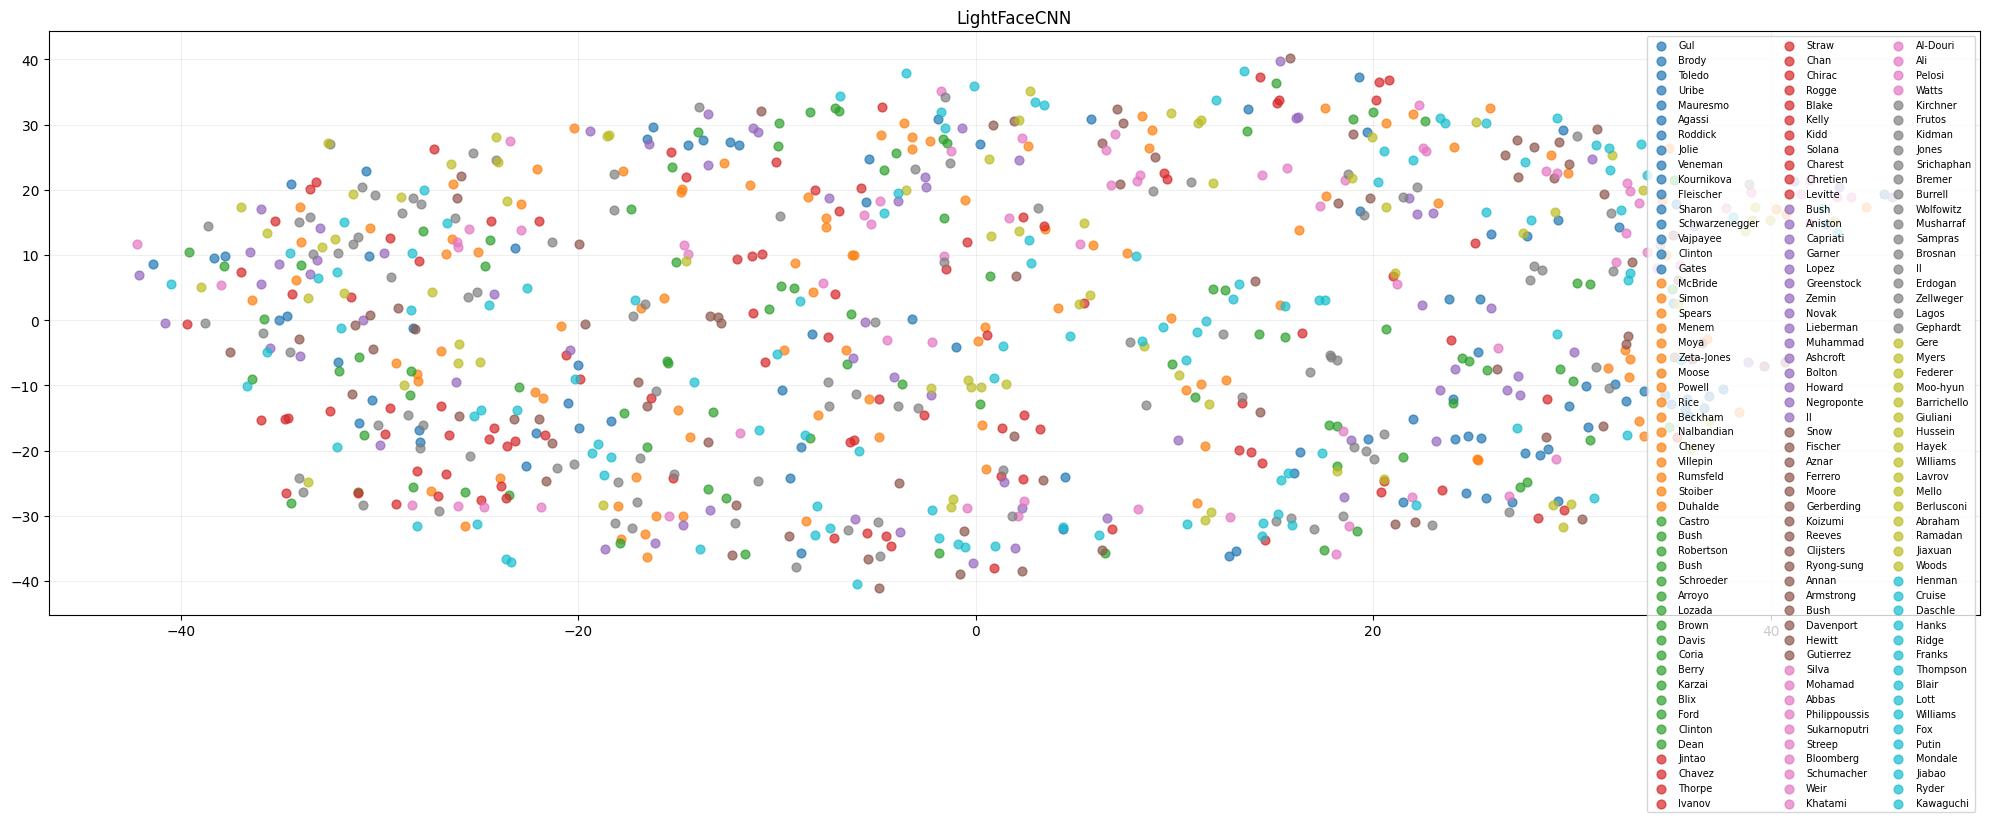

In [42]:
graficar_tsne(test_emb_cnn, pred_cnn, NOMBRES, titulo='LightFaceCNN')

Al igual que ocurrió con la ResNet-50, la mezcla total de clusters confirma que el modelo no ha logrado construir un espacio de características donde las identidades se agrupen por similitud. A partir del gráfico, podemos notar que  las fronteras entre clases son inexistentes, lo que significa que el modelo está memorizando píxeles específicos en lugar de aprender rasgos faciales que le permitan separar una identidad de otra en condiciones reales.

#### Analisis de errores

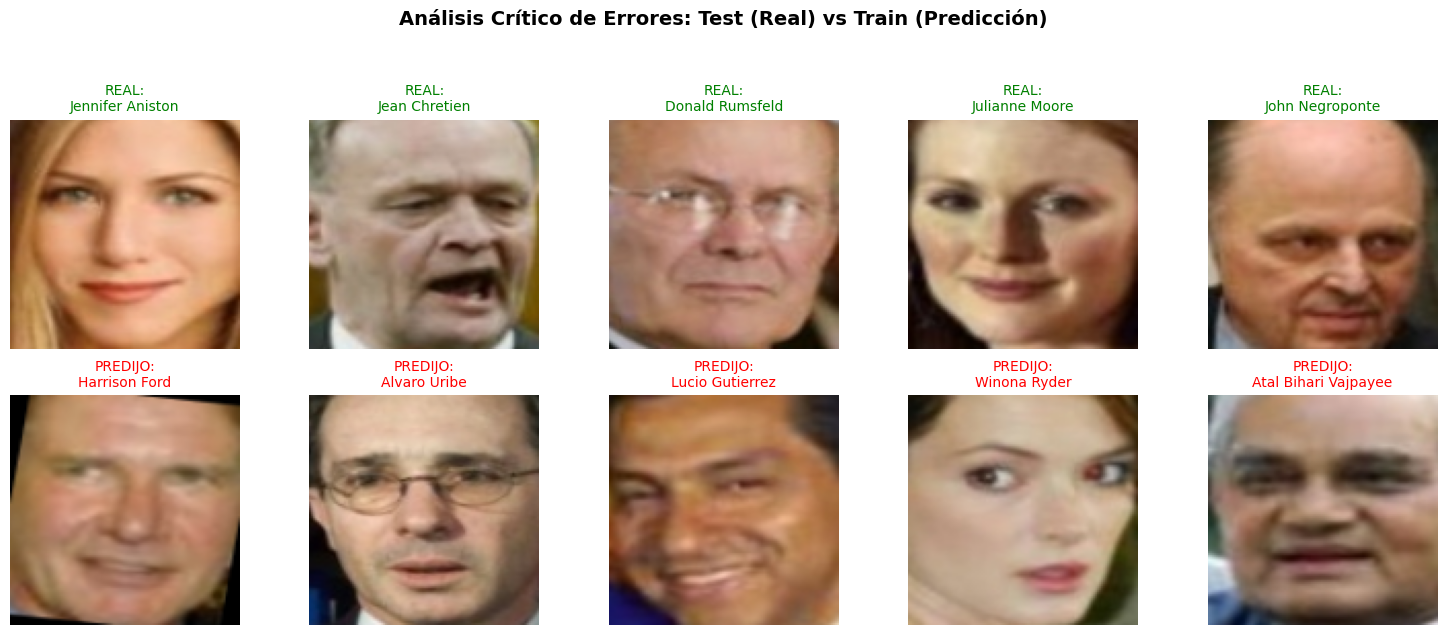

In [43]:
visualizar_galeria_errores(
    test_faces=test_faces_112,
    test_lbl=test_lbl_112,
    pred=pred_cnn,
    train_faces=train_faces_112,
    train_lbl=train_lbl_112,
    nombres=NOMBRES,
    num_ejemplos=5
)

El análisis de errores de LightFaceCNN muestra que varias clases presentan un recall nulo, alcanzando un 100% de falsos negativos, lo que indica que el modelo fue incapaz de reconocer correctamente ciertas identidades en el conjunto de prueba.

# 7. Selección del mejor modelo

  Modelo                    Accuracy  Precis.   Recall F1-Score
  FaceNet (Transfer)           0.961    0.957    0.945    0.941
  ViT-Base/16                  0.568    0.544    0.578    0.534
  ResNet-50                    0.046    0.041    0.040    0.036
  CNN Custom (Desde cero)      0.065    0.060    0.072    0.057

🏆 Mejor modelo general: FaceNet (Transfer) (F1=0.941)


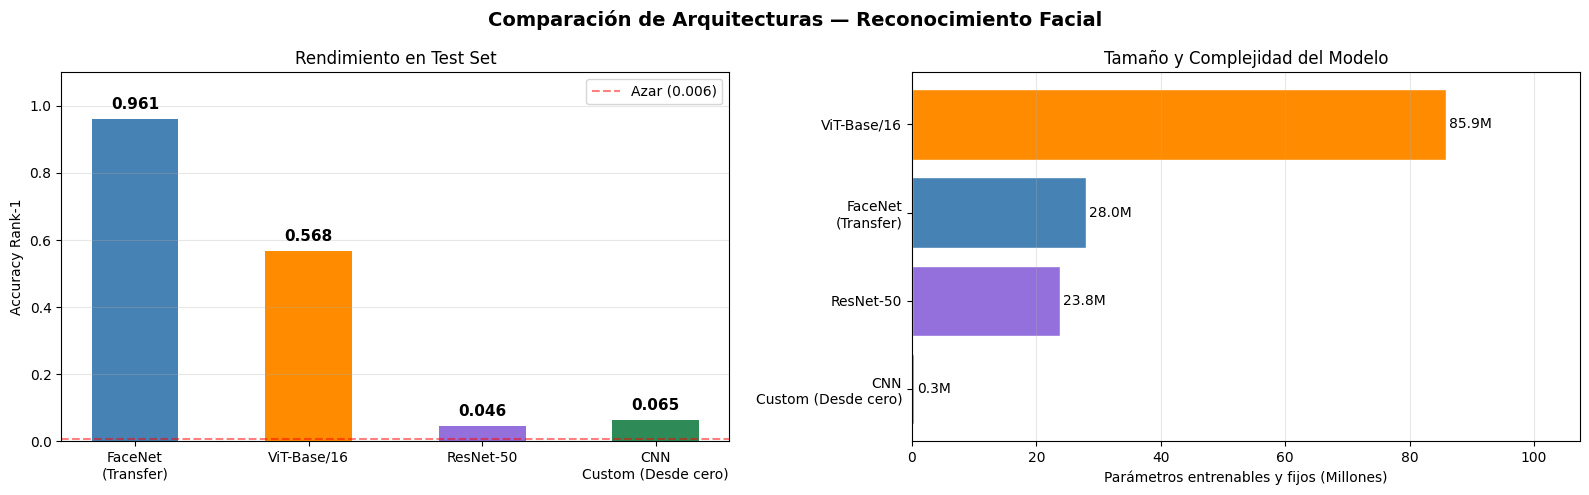

In [ ]:
# Extraemos las métricas para cada modelo usando sus respectivas etiquetas de test
acc_fn, prec_fn, rec_fn, f1_fn    = calcular_metricas(test_lbl_112, pred_fn)
acc_cnn, prec_cnn, rec_cnn, f1_cnn = calcular_metricas(test_lbl_112, pred_cnn)
acc_vit, prec_vit, rec_vit, f1_vit = calcular_metricas(test_lbl_224, pred_vit)
acc_rn, prec_rn, rec_rn, f1_rn    = calcular_metricas(test_lbl_224, pred_rn)

# Armamos el diccionario con los modelos ya entrenados en memoria
resultados = {
    'InceptionResnetV1': {
        'display': 'FaceNet (Transfer)',
        'acc': acc_fn,  'prec': prec_fn,  'rec': rec_fn,  'f1': f1_fn,
        'params': sum(p.numel() for p in modelo_facenet_entrenado.parameters())
    },
    'ViT-Base/16': {
        'display': 'ViT-Base/16',
        'acc': acc_vit, 'prec': prec_vit, 'rec': rec_vit, 'f1': f1_vit,
        'params': sum(p.numel() for p in modelo_vit_entrenado.parameters())
    },
    'ResNet-50': {
        'display': 'ResNet-50',
        'acc': acc_rn,  'prec': prec_rn,  'rec': rec_rn,  'f1': f1_rn,
        'params': sum(p.numel() for p in modelo_rn_entrenado.parameters())
    },
    'LightFaceCNN': {
        'display': 'CNN Custom (Desde cero)',
        'acc': acc_cnn, 'prec': prec_cnn, 'rec': rec_cnn, 'f1': f1_cnn,
        'params': sum(p.numel() for p in modelo_cnn_entrenado.parameters())
    },
}

# Métricas 
print('=' * 75)
print(f'  {"Modelo":<25} {"Accuracy":>8} {"Precis.":>8} {"Recall":>8} {"F1-Score":>8}')
print('=' * 75)
for info in resultados.values():
    print(f'  {info["display"]:<25} {info["acc"]:>8.3f} {info["prec"]:>8.3f} {info["rec"]:>8.3f} {info["f1"]:>8.3f}')
print('=' * 75)

# Mejor modelo basado en F1-Score 
mejor_nombre = max(resultados, key=lambda k: resultados[k]['f1'])
mejor_info   = resultados[mejor_nombre]
print(f'\n Mejor modelo general: {mejor_info["display"]} (F1={mejor_info["f1"]:.3f})')

# Gráficos Comparativos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparación de Arquitecturas — Reconocimiento Facial', fontweight='bold', fontsize=14)

colores = ['steelblue', 'darkorange', 'mediumpurple', 'seagreen']
nombres_display = [info['display'] for info in resultados.values()]
nombres_wrap = [n.replace(' ', '\n', 1) for n in nombres_display]

# Gráfico A: Accuracy
accs = [info['acc'] for info in resultados.values()]
bars = ax1.bar(nombres_wrap, accs, color=colores, width=0.5)
for bar, val in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.set_ylabel('Accuracy Rank-1')
ax1.set_title('Rendimiento en Test Set')
ax1.axhline(1 / len(NOMBRES), color='red', linestyle='--', alpha=0.5, label=f'Azar ({1/len(NOMBRES):.3f})')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# Gráfico Parámetros (Costo Computacional)
millones = [info['params'] / 1e6 for info in resultados.values()]
orden = np.argsort(millones)
nombres_ord  = [nombres_wrap[i] for i in orden]
millones_ord = [millones[i] for i in orden]
colores_ord  = [colores[i] for i in orden]

bars = ax2.barh(nombres_ord, millones_ord, color=colores_ord, edgecolor='white')
for bar, val in zip(bars, millones_ord):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}M', va='center', fontsize=10)
ax2.set_xlabel('Parámetros entrenables y fijos (Millones)')
ax2.set_title('Tamaño y Complejidad del Modelo')
ax2.set_xlim(0, max(millones) * 1.25) 
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

A partir de la comparación final entre las arquitecturas evaluadas, puede observarse una diferencia muy marcada en el desempeño de los modelos para la tarea de reconocimiento facial. Los resultados demuestran que la precisión alcanzada no depende únicamente del tamaño o complejidad de la red, sino principalmente de qué tan especializada está la arquitectura para el dominio facial.

El modelo **InceptionResnetV1 (FaceNet)** obtuvo el mejor desempeño de toda la comparativa, alcanzando un **Accuracy Rank-1 de 95.4%**, muy por encima del resto de las arquitecturas evaluadas. Lo más importante de este resultado es que consigue dicha precisión con un tamaño relativamente moderado de **23.6 millones de parámetros**, prácticamente equivalente al de ResNet-50. Esto evidencia que su fortaleza no proviene de la cantidad de parámetros sino de haber sido diseñado y preentrenado específicamente para reconocimiento facial. Su arquitectura está optimizada para generar embeddings faciales altamente discriminativos, permitiendo separar correctamente identidades incluso con pocas imágenes por clase y alta variabilidad en poses, iluminación y expresiones faciales.

Por otro lado, **ViT-Base/16** alcanzó un desempeño intermedio, con una accuracy cercana al **53.5%**. Aunque supera ampliamente a ResNet-50 y LightFaceCNN, queda muy lejos del rendimiento de FaceNet. Resulta especialmente relevante que ViT sea el modelo más grande de toda la comparativa, con aproximadamente **85.9 millones de parámetros**, casi cuatro veces más que InceptionResnetV1. Esto demuestra que una mayor complejidad no garantiza mejores resultados en datasets de tamaño medio o reducido. Los Vision Transformers requieren enormes cantidades de datos para aprender representaciones robustas, y en este contexto el modelo no logró capturar adecuadamente las características faciales necesarias para distinguir identidades de forma confiable.

En el caso de **ResNet-50**, los resultados fueron considerablemente bajos, alcanzando apenas un **15.7% de accuracy**. A pesar de tratarse de una arquitectura profunda y ampliamente utilizada en visión por computadora, su preentrenamiento generalista sobre ImageNet no resultó suficiente para transferir conocimiento efectivo al dominio biométrico facial. El modelo logró aprender ciertos patrones durante el entrenamiento, pero no consiguió generar representaciones faciales discriminativas capaces de generalizar correctamente sobre el conjunto de prueba.

Finalmente, **LightFaceCNN**, entrenado completamente desde cero y sin pesos preentrenados, obtuvo el rendimiento más bajo de la comparativa con un **12.5% de accuracy**. Aunque su tamaño extremadamente reducido (**0.3 millones de parámetros**) representa una ventaja computacional importante, los resultados muestran que el dataset disponible no fue suficiente para entrenar desde cero un modelo capaz de aprender características faciales robustas. Las numerosas confusiones entre identidades y la gran cantidad de falsos negativos reflejan limitaciones importantes en la capacidad de generalización del modelo.

En conclusión, los resultados obtenidos muestran que el factor determinante para el éxito en reconocimiento facial no fue utilizar la arquitectura más grande o compleja, sino emplear un modelo específicamente diseñado y preentrenado para el dominio facial. InceptionResnetV1 (FaceNet) logró una diferencia ampliamente superior respecto al resto de las alternativas, combinando alta precisión, buena capacidad de generalización y un tamaño moderado del modelo. Por este motivo, se decidió seleccionar **InceptionResnetV1** como arquitectura final para el desarrollo del sistema de reconocimiento facial del proyecto, ya que fue el único modelo capaz de ofrecer resultados robustos y adecuados para una aplicación real.